## Importing Important Packages

In [1]:
# pip install tensorflow

In [2]:
import numpy as np 
import pandas as pd
import math
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error 
from matplotlib import pyplot as plt
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [3]:
#setting random seed

tf.random.set_seed(1234)

# Last Study

To examine the last study done, we take a look at the dataset used to predict the performance of players. 

In [4]:
url="https://raw.githubusercontent.com/nguyen7594/isqs5381_summer19nn/master/src/nba_stat_merged.csv"
dataset_previous_study=pd.read_csv(url,delimiter=',') 
display(dataset_previous_study)

,Year,Player_,Tm,Pos,G,MP,Age,PTS,FG,FG%,...,ORB,ORB%,STL,STL%,TOV,TOV%,PF,WS,all_star_this_year,all_star_next_year
0,1980.0,Kareem Abdul-Jabbar,LAL,C,82.0,3143.0,32.0,2034.0,835.0,0.604,...,190.0,7.2,81.0,1.2,297.0,15.7,216.0,14.8,1.0,1.0
1,1980.0,Tom Abernethy,GSW,PF,67.0,1222.0,25.0,362.0,153.0,0.481,...,62.0,5.4,35.0,1.4,39.0,9.9,118.0,2.0,0.0,0.0
2,1980.0,Alvan Adams,PHO,C,75.0,2168.0,25.0,1118.0,465.0,0.531,...,158.0,8.2,108.0,2.3,218.0,18.2,237.0,7.0,0.0,0.0
3,1980.0,Tiny Archibald,BOS,PG,80.0,2864.0,31.0,1131.0,383.0,0.482,...,59.0,2.3,106.0,1.7,242.0,19.7,218.0,8.9,1.0,1.0
4,1980.0,Dennis Awtrey,CHI,C,26.0,560.0,31.0,86.0,27.0,0.450,...,29.0,6.0,12.0,1.0,27.0,24.8,66.0,0.6,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15076,2017.0,Cody Zeller,CHO,PF,62.0,1725.0,24.0,639.0,253.0,0.571,...,135.0,8.6,62.0,1.8,65.0,10.9,189.0,5.6,0.0,0.0
15077,2017.0,Tyler Zeller,BOS,C,51.0,525.0,27.0,178.0,78.0,0.494,...,43.0,9.2,7.0,0.7,20.0,10.2,61.0,1.0,0.0,0.0
15078,2017.0,Stephen Zimmerman,ORL,C,19.0,108.0,20.0,23.0,10.0,0.323,...,11.0,10.8,2.0,0.9,3.0,8.3,17.0,0.0,0.0,0.0
15079,2017.0,Paul Zipser,CHI,SF,44.0,843.0,22.0,240.0,88.0,0.398,...,15.0,1.9,15.0,0.9,40.0,14.4,78.0,0.5,0.0,0.0


From the analysis of the dataset it just has 32 features i.e. different types of stats. Additionally, as mentioned in the paper (https://www.tandfonline.com/doi/full/10.1080/24751839.2021.1977066) this dataset is producing an MAE of 4.32 on the best performing DL model. 

# Current Dissertation

This is where we start our work by importing and analysing different datasets. 

In [5]:
player_league_info = pd.read_csv('player_data.csv', delimiter=',') #Dataset containing player league information from 1950 to 2017
display(player_league_info)

,name,year_start,year_end,position,height,weight,birth_date,college
0,Alaa Abdelnaby,1991,1995,F-C,6-10,240.0,"June 24, 1968",Duke University
1,Zaid Abdul-Aziz,1969,1978,C-F,6-9,235.0,"April 7, 1946",Iowa State University
2,Kareem Abdul-Jabbar,1970,1989,C,7-2,225.0,"April 16, 1947","University of California, Los Angeles"
3,Mahmoud Abdul-Rauf,1991,2001,G,6-1,162.0,"March 9, 1969",Louisiana State University
4,Tariq Abdul-Wahad,1998,2003,F,6-6,223.0,"November 3, 1974",San Jose State University
...,...,...,...,...,...,...,...,...
4545,Ante Zizic,2018,2018,F-C,6-11,250.0,"January 4, 1997",NaN
4546,Jim Zoet,1983,1983,C,7-1,240.0,"December 20, 1953",Kent State University
4547,Bill Zopf,1971,1971,G,6-1,170.0,"June 7, 1948",Duquesne University
4548,Ivica Zubac,2017,2018,C,7-1,265.0,"March 18, 1997",NaN


In [6]:
season_stats = pd.read_csv('Seasons_Stats.csv', delimiter=',') #Dataset containing season stats from 1950 to 2017
display(season_stats)

,Unnamed: 0,Year,Player,Pos,Age,Tm,G,GS,MP,PER,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,0,1950.0,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,NaN,NaN,...,0.705,NaN,NaN,NaN,176.0,NaN,NaN,NaN,217.0,458.0
1,1,1950.0,Cliff Barker,SG,29.0,INO,49.0,NaN,NaN,NaN,...,0.708,NaN,NaN,NaN,109.0,NaN,NaN,NaN,99.0,279.0
2,2,1950.0,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,NaN,NaN,...,0.698,NaN,NaN,NaN,140.0,NaN,NaN,NaN,192.0,438.0
3,3,1950.0,Ed Bartels,F,24.0,TOT,15.0,NaN,NaN,NaN,...,0.559,NaN,NaN,NaN,20.0,NaN,NaN,NaN,29.0,63.0
4,4,1950.0,Ed Bartels,F,24.0,DNN,13.0,NaN,NaN,NaN,...,0.548,NaN,NaN,NaN,20.0,NaN,NaN,NaN,27.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24686,24686,2017.0,Cody Zeller,PF,24.0,CHO,62.0,58.0,1725.0,16.7,...,0.679,135.0,270.0,405.0,99.0,62.0,58.0,65.0,189.0,639.0
24687,24687,2017.0,Tyler Zeller,C,27.0,BOS,51.0,5.0,525.0,13.0,...,0.564,43.0,81.0,124.0,42.0,7.0,21.0,20.0,61.0,178.0
24688,24688,2017.0,Stephen Zimmerman,C,20.0,ORL,19.0,0.0,108.0,7.3,...,0.600,11.0,24.0,35.0,4.0,2.0,5.0,3.0,17.0,23.0
24689,24689,2017.0,Paul Zipser,SF,22.0,CHI,44.0,18.0,843.0,6.9,...,0.775,15.0,110.0,125.0,36.0,15.0,16.0,40.0,78.0,240.0


We are mainly concerned with the regular season statistics and hence, we will proceed the dataset containing the season statistics of the players from 1950 to 2017

## Dataset Preprocessing

As our Initial Data contains much inconsistent data and noise, we need to undertake some steps apart from standard dataset processing to obtain a clean dataset to work on.

In [7]:
#Dropping unwanted columns
season_stats.drop(columns= ['blanl','blank2','Unnamed: 0',], inplace = True)

#Dropping Empty rows
season_stats['Year'].replace(np.nan,0, inplace=True)
season_stats.drop(season_stats[season_stats.Year == 0].index, inplace=True)

In [8]:
season_stats

,Year,Player,Pos,Age,Tm,G,GS,MP,PER,TS%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1950.0,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,NaN,NaN,0.368,...,0.705,NaN,NaN,NaN,176.0,NaN,NaN,NaN,217.0,458.0
1,1950.0,Cliff Barker,SG,29.0,INO,49.0,NaN,NaN,NaN,0.435,...,0.708,NaN,NaN,NaN,109.0,NaN,NaN,NaN,99.0,279.0
2,1950.0,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,NaN,NaN,0.394,...,0.698,NaN,NaN,NaN,140.0,NaN,NaN,NaN,192.0,438.0
3,1950.0,Ed Bartels,F,24.0,TOT,15.0,NaN,NaN,NaN,0.312,...,0.559,NaN,NaN,NaN,20.0,NaN,NaN,NaN,29.0,63.0
4,1950.0,Ed Bartels,F,24.0,DNN,13.0,NaN,NaN,NaN,0.308,...,0.548,NaN,NaN,NaN,20.0,NaN,NaN,NaN,27.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24686,2017.0,Cody Zeller,PF,24.0,CHO,62.0,58.0,1725.0,16.7,0.604,...,0.679,135.0,270.0,405.0,99.0,62.0,58.0,65.0,189.0,639.0
24687,2017.0,Tyler Zeller,C,27.0,BOS,51.0,5.0,525.0,13.0,0.508,...,0.564,43.0,81.0,124.0,42.0,7.0,21.0,20.0,61.0,178.0
24688,2017.0,Stephen Zimmerman,C,20.0,ORL,19.0,0.0,108.0,7.3,0.346,...,0.600,11.0,24.0,35.0,4.0,2.0,5.0,3.0,17.0,23.0
24689,2017.0,Paul Zipser,SF,22.0,CHI,44.0,18.0,843.0,6.9,0.503,...,0.775,15.0,110.0,125.0,36.0,15.0,16.0,40.0,78.0,240.0


#### Removal of Years before 1980 and GS

We will drop the instances before the year 1980 and Games Started feature from our dataset because of too much inconsistent Data

In [9]:
#Dropping stats before 1980 because of too much inconsistent Data

season_stats.drop(season_stats[season_stats.Year < 1980].index, inplace=True)

season_stats.drop(columns= ["GS"], inplace = True)

In [10]:
season_stats

,Year,Player,Pos,Age,Tm,G,MP,PER,TS%,3PAr,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
5727,1980.0,Kareem Abdul-Jabbar*,C,32.0,LAL,82.0,3143.0,25.3,0.639,0.001,...,0.765,190.0,696.0,886.0,371.0,81.0,280.0,297.0,216.0,2034.0
5728,1980.0,Tom Abernethy,PF,25.0,GSW,67.0,1222.0,11.0,0.511,0.003,...,0.683,62.0,129.0,191.0,87.0,35.0,12.0,39.0,118.0,362.0
5729,1980.0,Alvan Adams,C,25.0,PHO,75.0,2168.0,19.2,0.571,0.002,...,0.797,158.0,451.0,609.0,322.0,108.0,55.0,218.0,237.0,1118.0
5730,1980.0,Tiny Archibald*,PG,31.0,BOS,80.0,2864.0,15.3,0.574,0.023,...,0.830,59.0,138.0,197.0,671.0,106.0,10.0,242.0,218.0,1131.0
5731,1980.0,Dennis Awtrey,C,31.0,CHI,26.0,560.0,7.4,0.524,0.000,...,0.640,29.0,86.0,115.0,40.0,12.0,15.0,27.0,66.0,86.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24686,2017.0,Cody Zeller,PF,24.0,CHO,62.0,1725.0,16.7,0.604,0.002,...,0.679,135.0,270.0,405.0,99.0,62.0,58.0,65.0,189.0,639.0
24687,2017.0,Tyler Zeller,C,27.0,BOS,51.0,525.0,13.0,0.508,0.006,...,0.564,43.0,81.0,124.0,42.0,7.0,21.0,20.0,61.0,178.0
24688,2017.0,Stephen Zimmerman,C,20.0,ORL,19.0,108.0,7.3,0.346,0.000,...,0.600,11.0,24.0,35.0,4.0,2.0,5.0,3.0,17.0,23.0
24689,2017.0,Paul Zipser,SF,22.0,CHI,44.0,843.0,6.9,0.503,0.448,...,0.775,15.0,110.0,125.0,36.0,15.0,16.0,40.0,78.0,240.0


### Analysing NaN

Deep learning models requires no feature to contain any null values hence we need to list all features containing  NaN values and deal with them seperately 

In [11]:
col = season_stats.columns
print("All features: ")
print(col)

#List of all features containing null values
features_with_na = []

#Checking for Nan
for i in range(len(col)):
  check_for_nan = season_stats[col[i]].isnull().values.any()
  if check_for_nan == True: 
    features_with_na.append(col[i])

print("Features containing Null values: ")
print(features_with_na)

#Counting NaN values

for i in features_with_na:
  print(i) 
  count_nan = season_stats[i].isnull().sum()
  print ('Count of NaN: ' + str(count_nan))

All features: 
Index(['Year', 'Player', 'Pos', 'Age', 'Tm', 'G', 'MP', 'PER', 'TS%', '3PAr',
       'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%',
       'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')
Features containing Null values: 
['PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'WS/48', 'FG%', '3P%', '2P%', 'eFG%', 'FT%']
PER
Count of NaN: 5
TS%
Count of NaN: 76
3PAr
Count of NaN: 88
FTr
Count of NaN: 88
ORB%
Count of NaN: 5
DRB%
Count of NaN: 5
TRB%
Count of NaN: 5
AST%
Count of NaN: 5
STL%
Count of NaN: 5
BLK%
Count of NaN: 5
TOV%
Count of NaN: 61
USG%
Count of NaN: 5
WS/48
Count of NaN: 5
FG%
Count of NaN: 88
3P%
Count of NaN: 3511
2P%
Count of NaN: 117
eFG%
Count of NaN: 88
FT%
Count of NaN: 745


#### Zero MP

If the player hasn't played any minutes for the season then we can't predict his performance and hence the player must be dropped

In [12]:
#Dropping  the instances with 0 minutes played in the whole season

col = season_stats['MP']
zero_MP = []
for i in col.index:
  if col[i] == 0:
    print(i)
    print(season_stats[['Year','Player','MP']].loc[i])
    zero_MP.append(i)

season_stats.drop(index=zero_MP,inplace= True)

17787
Year            2006
Player    Josh Davis
MP                 0
Name: 17787, dtype: object
18104
Year             2006
Player    Alex Scales
MP                  0
Name: 18104, dtype: object
19069
Year                2008
Player    Stephane Lasme
MP                     0
Name: 19069, dtype: object
20041
Year               2010
Player    JamesOn Curry
MP                    0
Name: 20041, dtype: object
21932
Year              2013
Player    Damion James
MP                   0
Name: 21932, dtype: object


We will recheck to see what effect of dropping the players with 0 Minutes Played has on null values of our dataset

In [13]:
#Rechecking for the columns with Null values with effect of dropping the players with 0 minutes played

col = season_stats.columns
print("All features: ")
print(col)

#List of all features containing null values
features_with_na = []

#Checking for Nan
for i in range(len(col)):
  check_for_nan = season_stats[col[i]].isnull().values.any()
  if check_for_nan == True: 
    features_with_na.append(col[i])

print("Features containing Null values: ")
print(features_with_na)

#Counting NaN values

for i in features_with_na:
  print(i) 
  count_nan = season_stats[i].isnull().sum()
  print ('Count of NaN: ' + str(count_nan))

All features: 
Index(['Year', 'Player', 'Pos', 'Age', 'Tm', 'G', 'MP', 'PER', 'TS%', '3PAr',
       'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%',
       'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')
Features containing Null values: 
['TS%', '3PAr', 'FTr', 'TOV%', 'FG%', '3P%', '2P%', 'eFG%', 'FT%']
TS%
Count of NaN: 71
3PAr
Count of NaN: 83
FTr
Count of NaN: 83
TOV%
Count of NaN: 56
FG%
Count of NaN: 83
3P%
Count of NaN: 3506
2P%
Count of NaN: 112
eFG%
Count of NaN: 83
FT%
Count of NaN: 740


From above we can see that removing players who haven't played a game is diminishing the NaN values and the features containing NaN values are also lessened

#### Minimal Games

The players playing less than 5 games act as a noise due to very drastic statistics when compared to players playing substantial amount of games and hence dropping them is feasiable to the model

In [14]:
#Listing and dropping the players with less than 5 games played 

col = season_stats['G']
Least_G = []

for i in col.index:  
  if col[i] < 5:
    Least_G.append(i)
print("Number of players playing less than 5 games: ")
print(len(Least_G))

season_stats.drop(index=Least_G,inplace= True)

Number of players playing less than 5 games: 
986


We will again recheck to see what effect of dropping the players with minimal games has on null values of our dataset

In [15]:
#Rechecking for the columns with Null values with effect of dropping the players with 0 minutes played

col = season_stats.columns
print("All features: ")
print(col)

#List of all features containing null values
features_with_na = []

#Checking for Nan
for i in range(len(col)):
  check_for_nan = season_stats[col[i]].isnull().values.any()
  if check_for_nan == True: 
    features_with_na.append(col[i])

print("Features containing Null values: ")
print(features_with_na)

#Counting NaN values

for i in features_with_na:
  print(i) 
  count_nan = season_stats[i].isnull().sum()
  print ('Count of NaN: ' + str(count_nan))

All features: 
Index(['Year', 'Player', 'Pos', 'Age', 'Tm', 'G', 'MP', 'PER', 'TS%', '3PAr',
       'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%',
       'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')
Features containing Null values: 
['3PAr', 'FTr', 'FG%', '3P%', '2P%', 'eFG%', 'FT%']
3PAr
Count of NaN: 3
FTr
Count of NaN: 3
FG%
Count of NaN: 3
3P%
Count of NaN: 2869
2P%
Count of NaN: 7
eFG%
Count of NaN: 3
FT%
Count of NaN: 254


From above we can see that removing players with minimal games have dimisnished the NaN values and the features containing NaN values are also reduced

#### Zero 3P Attempts

If a player didn't attempt a single 3-Pointer then his 3-Point % must be 0.

In [16]:
#Collecting the players who didn't attempt a single 3 pointer and making their 3 point percentage 0
col = season_stats['3PA']
zero_3PAr = []

for i in col.index:
  if col[i] == 0:
    zero_3PAr.append(i)
   
print("Number of players with 0 3-Point Attempts: ")
print(len(zero_3PAr))

for i in zero_3PAr:
  season_stats.at[i,'3P%'] = 0

Number of players with 0 3-Point Attempts: 
2869


We will recheck to see what effect of making 3P% zero  has on features with  null values of our dataset

In [17]:
#Rechecking for the columns with Null values with effect of dropping the players with 0 minutes played

col = season_stats.columns
print("All features: ")
print(col)

#List of all features containing null values
features_with_na = []

#Checking for Nan
for i in range(len(col)):
  check_for_nan = season_stats[col[i]].isnull().values.any()
  if check_for_nan == True: 
    features_with_na.append(col[i])

print("Features containing Null values: ")
print(features_with_na)

#Counting NaN values

for i in features_with_na:
  print(i) 
  count_nan = season_stats[i].isnull().sum()
  print ('Count of NaN: ' + str(count_nan))

All features: 
Index(['Year', 'Player', 'Pos', 'Age', 'Tm', 'G', 'MP', 'PER', 'TS%', '3PAr',
       'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%',
       'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')
Features containing Null values: 
['3PAr', 'FTr', 'FG%', '2P%', 'eFG%', 'FT%']
3PAr
Count of NaN: 3
FTr
Count of NaN: 3
FG%
Count of NaN: 3
2P%
Count of NaN: 7
eFG%
Count of NaN: 3
FT%
Count of NaN: 254


From above we can see that this dataprocessing step has diminished the NaN values and the features containing null values have also reduced

#### Zero 2P Attempts

If a player didn't attempt a single 2-Pointer then his 2-Point % must be 0.

In [18]:
#Collecting the players who didn't attempt a single 2 pointer and making their 2 point percentage 0
col = season_stats['2PA']
zero_2PA = []

for i in col.index:
  if col[i] == 0:
    zero_2PA.append(i)
    
print("The number of players without attempting a 2 pointer")
print(len(zero_2PA))

for i in zero_2PA:
  season_stats.at[i,'2P%'] = 0

The number of players without attempting a 2 pointer
7


We will recheck to see what effect of making 2P% zero  has on features with  null values of our dataset

In [19]:
#Rechecking for the columns with Null values with effect of dropping the players with 0 minutes played

col = season_stats.columns
print("All features: ")
print(col)

#List of all features containing null values
features_with_na = []

#Checking for Nan
for i in range(len(col)):
  check_for_nan = season_stats[col[i]].isnull().values.any()
  if check_for_nan == True: 
    features_with_na.append(col[i])

print("Features containing Null values: ")
print(features_with_na)

#Counting NaN values

for i in features_with_na:
  print(i) 
  count_nan = season_stats[i].isnull().sum()
  print ('Count of NaN: ' + str(count_nan))

All features: 
Index(['Year', 'Player', 'Pos', 'Age', 'Tm', 'G', 'MP', 'PER', 'TS%', '3PAr',
       'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%',
       'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')
Features containing Null values: 
['3PAr', 'FTr', 'FG%', 'eFG%', 'FT%']
3PAr
Count of NaN: 3
FTr
Count of NaN: 3
FG%
Count of NaN: 3
eFG%
Count of NaN: 3
FT%
Count of NaN: 254


From above we can see this have dimisnished the NaN values and the features containing NaN values are also reduced

#### Zero FT %

If a player didn't attempt a single free throw then his Free throw % must be 0.

In [20]:
#Analysing the players will null values in Free throw and making it 0 cause they didn't attempt a single free throw

col = season_stats['FT%']
Zero_FT = []
for i in col.index:
  if math.isnan(col[i]) == True:
    # print(season_stats[['Year','Player','G']].loc[i])
    Zero_FT.append(i)

print("The number of players with 0 free throw: ")
print(len(Zero_FT))

for i in Zero_FT:
  season_stats.at[i,'FT%'] = 0

The number of players with 0 free throw: 
254


We will recheck to see what effect of making FT% zero  has on features with  null values of our dataset

In [21]:
#Rechecking for the columns with Null values with effect of dropping the players with 0 minutes played

col = season_stats.columns
print("All features: ")
print(col)

#List of all features containing null values
features_with_na = []

#Checking for Nan
for i in range(len(col)):
  check_for_nan = season_stats[col[i]].isnull().values.any()
  if check_for_nan == True: 
    features_with_na.append(col[i])

print("Features containing Null values: ")
print(features_with_na)

#Counting NaN values

for i in features_with_na:
  print(i) 
  count_nan = season_stats[i].isnull().sum()
  print ('Count of NaN: ' + str(count_nan))

All features: 
Index(['Year', 'Player', 'Pos', 'Age', 'Tm', 'G', 'MP', 'PER', 'TS%', '3PAr',
       'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%',
       'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')
Features containing Null values: 
['3PAr', 'FTr', 'FG%', 'eFG%']
3PAr
Count of NaN: 3
FTr
Count of NaN: 3
FG%
Count of NaN: 3
eFG%
Count of NaN: 3


From above we can see that our dataprocessing step is diminishing the NaN values and the features containing null values are also diminishing

Now we have just remained with 3 players who have inconsistent stats in a certain year. This is either because they were benched or suffered from injury. Having researched about their stats, we got to know that they all their 3 Point Attempts, Free Throw Attempts, Feild Goals and Effective Field Goal were all 0, they haven't just recorded yet and hence we make it 0.

In [22]:
#Analysing which players and for what year are they producing null stats in different categories

NA_cols = ['3PAr', 'FTr', 'FG%', 'eFG%']
for na in NA_cols:
  print(na)
  
  col = season_stats[na]
  for i in col.index:
    if math.isnan(col[i]) == True:
      print(season_stats[['Year','Player']].loc[i])


#After retriveing their index, we make their null stats as 0
odd_index = [9712,16920,17493]
def make_zero(stat):
  for i in odd_index: 
    season_stats.at[i,stat] = 0

make_zero('3PAr')
make_zero('FTr')
make_zero('FG%')
make_zero('eFG%')

3PAr
Year              1990
Player    Mike Higgins
Name: 9712, dtype: object
Year                2004
Player    Joel Przybilla
Name: 16920, dtype: object
Year                 2005
Player    Pavel Podkolzin
Name: 17493, dtype: object
FTr
Year              1990
Player    Mike Higgins
Name: 9712, dtype: object
Year                2004
Player    Joel Przybilla
Name: 16920, dtype: object
Year                 2005
Player    Pavel Podkolzin
Name: 17493, dtype: object
FG%
Year              1990
Player    Mike Higgins
Name: 9712, dtype: object
Year                2004
Player    Joel Przybilla
Name: 16920, dtype: object
Year                 2005
Player    Pavel Podkolzin
Name: 17493, dtype: object
eFG%
Year              1990
Player    Mike Higgins
Name: 9712, dtype: object
Year                2004
Player    Joel Przybilla
Name: 16920, dtype: object
Year                 2005
Player    Pavel Podkolzin
Name: 17493, dtype: object


Finally checking if our dataset has any null values

In [23]:
season_stats.isnull().values.any()

False

Resetting the index

In [24]:
season_stats.reset_index(drop=True,inplace=True)
season_stats

,Year,Player,Pos,Age,Tm,G,MP,PER,TS%,3PAr,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1980.0,Kareem Abdul-Jabbar*,C,32.0,LAL,82.0,3143.0,25.3,0.639,0.001,...,0.765,190.0,696.0,886.0,371.0,81.0,280.0,297.0,216.0,2034.0
1,1980.0,Tom Abernethy,PF,25.0,GSW,67.0,1222.0,11.0,0.511,0.003,...,0.683,62.0,129.0,191.0,87.0,35.0,12.0,39.0,118.0,362.0
2,1980.0,Alvan Adams,C,25.0,PHO,75.0,2168.0,19.2,0.571,0.002,...,0.797,158.0,451.0,609.0,322.0,108.0,55.0,218.0,237.0,1118.0
3,1980.0,Tiny Archibald*,PG,31.0,BOS,80.0,2864.0,15.3,0.574,0.023,...,0.830,59.0,138.0,197.0,671.0,106.0,10.0,242.0,218.0,1131.0
4,1980.0,Dennis Awtrey,C,31.0,CHI,26.0,560.0,7.4,0.524,0.000,...,0.640,29.0,86.0,115.0,40.0,12.0,15.0,27.0,66.0,86.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,2017.0,Cody Zeller,PF,24.0,CHO,62.0,1725.0,16.7,0.604,0.002,...,0.679,135.0,270.0,405.0,99.0,62.0,58.0,65.0,189.0,639.0
17932,2017.0,Tyler Zeller,C,27.0,BOS,51.0,525.0,13.0,0.508,0.006,...,0.564,43.0,81.0,124.0,42.0,7.0,21.0,20.0,61.0,178.0
17933,2017.0,Stephen Zimmerman,C,20.0,ORL,19.0,108.0,7.3,0.346,0.000,...,0.600,11.0,24.0,35.0,4.0,2.0,5.0,3.0,17.0,23.0
17934,2017.0,Paul Zipser,SF,22.0,CHI,44.0,843.0,6.9,0.503,0.448,...,0.775,15.0,110.0,125.0,36.0,15.0,16.0,40.0,78.0,240.0


From above we can see that our dataprocessing steps have resulted in extraction of all the null values from all the features. 

### Player Name Correction

We can see that some players name contain a "*" attached to them for no possible reason and hence we remove that from our players names.

In [25]:
#Code used from last researcher (https://www.tandfonline.com/doi/full/10.1080/24751839.2021.1977066)

def remove_star(player_name):
    if player_name[-1] == '*':
        return player_name.strip()[:-1]
    else:
        return player_name.strip()
    
season_stats['Player'] = season_stats['Player'].map(lambda player: remove_star(player))

In [26]:
season_stats

,Year,Player,Pos,Age,Tm,G,MP,PER,TS%,3PAr,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1980.0,Kareem Abdul-Jabbar,C,32.0,LAL,82.0,3143.0,25.3,0.639,0.001,...,0.765,190.0,696.0,886.0,371.0,81.0,280.0,297.0,216.0,2034.0
1,1980.0,Tom Abernethy,PF,25.0,GSW,67.0,1222.0,11.0,0.511,0.003,...,0.683,62.0,129.0,191.0,87.0,35.0,12.0,39.0,118.0,362.0
2,1980.0,Alvan Adams,C,25.0,PHO,75.0,2168.0,19.2,0.571,0.002,...,0.797,158.0,451.0,609.0,322.0,108.0,55.0,218.0,237.0,1118.0
3,1980.0,Tiny Archibald,PG,31.0,BOS,80.0,2864.0,15.3,0.574,0.023,...,0.830,59.0,138.0,197.0,671.0,106.0,10.0,242.0,218.0,1131.0
4,1980.0,Dennis Awtrey,C,31.0,CHI,26.0,560.0,7.4,0.524,0.000,...,0.640,29.0,86.0,115.0,40.0,12.0,15.0,27.0,66.0,86.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,2017.0,Cody Zeller,PF,24.0,CHO,62.0,1725.0,16.7,0.604,0.002,...,0.679,135.0,270.0,405.0,99.0,62.0,58.0,65.0,189.0,639.0
17932,2017.0,Tyler Zeller,C,27.0,BOS,51.0,525.0,13.0,0.508,0.006,...,0.564,43.0,81.0,124.0,42.0,7.0,21.0,20.0,61.0,178.0
17933,2017.0,Stephen Zimmerman,C,20.0,ORL,19.0,108.0,7.3,0.346,0.000,...,0.600,11.0,24.0,35.0,4.0,2.0,5.0,3.0,17.0,23.0
17934,2017.0,Paul Zipser,SF,22.0,CHI,44.0,843.0,6.9,0.503,0.448,...,0.775,15.0,110.0,125.0,36.0,15.0,16.0,40.0,78.0,240.0


### Correlation Analysis

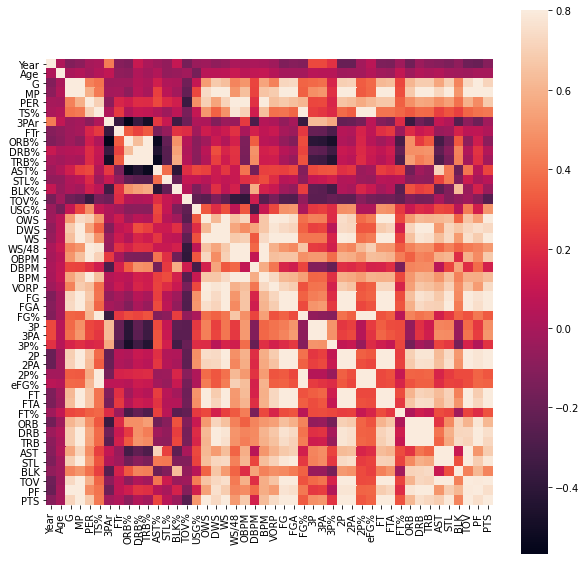

In [28]:
#Pefroming Correlation Analysis with the help of heatmap from seaborn library 
C_mat = season_stats.corr()
fig = plt.figure(figsize = (15,15))

sb.heatmap(C_mat, vmax = .8, square = True)
plt.gcf().set_size_inches(10,10)
plt.show()

### Label Encoding for Player Position

The catergorical feature Player Position is encoded according to traditional basketball posisitons.

In [29]:
#Defining a function to categorise every label

def create_label(x):
    if x == 'PG':
        return 1  
    if x == 'SG':
        return 2 
    if x == 'SF':
        return 3 
    if x == 'PF':
        return 4
    if x == 'C':
        return 5
    if x == 'PG-SG' or 'SG-PG':
      return 1.5
    if x == 'SG-SF' or 'SF-SG':
        return 2.5  
    if x == 'SF-PF' or 'PF-SF':
        return 3.5
    if x == 'PF-C' or 'C-PF':
        return 4.5 

#Every position is labelled according to a numerical value represting it's position
season_stats['Pos'] = season_stats['Pos'].apply(create_label)

In [30]:
season_stats

,Year,Player,Pos,Age,Tm,G,MP,PER,TS%,3PAr,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1980.0,Kareem Abdul-Jabbar,5.0,32.0,LAL,82.0,3143.0,25.3,0.639,0.001,...,0.765,190.0,696.0,886.0,371.0,81.0,280.0,297.0,216.0,2034.0
1,1980.0,Tom Abernethy,4.0,25.0,GSW,67.0,1222.0,11.0,0.511,0.003,...,0.683,62.0,129.0,191.0,87.0,35.0,12.0,39.0,118.0,362.0
2,1980.0,Alvan Adams,5.0,25.0,PHO,75.0,2168.0,19.2,0.571,0.002,...,0.797,158.0,451.0,609.0,322.0,108.0,55.0,218.0,237.0,1118.0
3,1980.0,Tiny Archibald,1.0,31.0,BOS,80.0,2864.0,15.3,0.574,0.023,...,0.830,59.0,138.0,197.0,671.0,106.0,10.0,242.0,218.0,1131.0
4,1980.0,Dennis Awtrey,5.0,31.0,CHI,26.0,560.0,7.4,0.524,0.000,...,0.640,29.0,86.0,115.0,40.0,12.0,15.0,27.0,66.0,86.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,2017.0,Cody Zeller,4.0,24.0,CHO,62.0,1725.0,16.7,0.604,0.002,...,0.679,135.0,270.0,405.0,99.0,62.0,58.0,65.0,189.0,639.0
17932,2017.0,Tyler Zeller,5.0,27.0,BOS,51.0,525.0,13.0,0.508,0.006,...,0.564,43.0,81.0,124.0,42.0,7.0,21.0,20.0,61.0,178.0
17933,2017.0,Stephen Zimmerman,5.0,20.0,ORL,19.0,108.0,7.3,0.346,0.000,...,0.600,11.0,24.0,35.0,4.0,2.0,5.0,3.0,17.0,23.0
17934,2017.0,Paul Zipser,3.0,22.0,CHI,44.0,843.0,6.9,0.503,0.448,...,0.775,15.0,110.0,125.0,36.0,15.0,16.0,40.0,78.0,240.0


### OHE for Categorical features

As a DL model requires all features to be numerical , we will perform One Hot Encoding for our two categorical features namely Team and Player Name

In [31]:
#Categorical columns

categorical_cols = ['Tm','Player']

#One Hot Encoding

def feature_encoding(dataset,columns):
    for col in columns:
        if( dataset[col].dtype == np.dtype('object')):
            dummies = pd.get_dummies(dataset[col],prefix=col)
            dataset = pd.concat([dataset,dummies],axis=1)

            #drop the encoded column
            dataset.drop([col],axis = 1 , inplace=True)
    return dataset
    

print('Number of columns before encoding categorical features: ', season_stats.shape[1])

season_stats = feature_encoding(season_stats, categorical_cols)
print('Number of columns after encoding categorical features: ' , season_stats.shape[1])

Number of columns before encoding categorical features:  49
Number of columns after encoding categorical features:  2768


In [32]:
season_stats

,Year,Pos,Age,G,MP,PER,TS%,3PAr,FTr,ORB%,...,Player_Zach Randolph,Player_Zan Tabak,Player_Zarko Cabarkapa,Player_Zarko Paspalj,Player_Zaza Pachulia,Player_Zeljko Rebraca,Player_Zendon Hamilton,Player_Zoran Dragic,Player_Zoran Planinic,Player_Zydrunas Ilgauskas
0,1980.0,5.0,32.0,82.0,3143.0,25.3,0.639,0.001,0.344,7.2,...,0,0,0,0,0,0,0,0,0,0
1,1980.0,4.0,25.0,67.0,1222.0,11.0,0.511,0.003,0.258,5.4,...,0,0,0,0,0,0,0,0,0,0
2,1980.0,5.0,25.0,75.0,2168.0,19.2,0.571,0.002,0.270,8.2,...,0,0,0,0,0,0,0,0,0,0
3,1980.0,1.0,31.0,80.0,2864.0,15.3,0.574,0.023,0.548,2.3,...,0,0,0,0,0,0,0,0,0,0
4,1980.0,5.0,31.0,26.0,560.0,7.4,0.524,0.000,0.833,6.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,2017.0,4.0,24.0,62.0,1725.0,16.7,0.604,0.002,0.442,8.6,...,0,0,0,0,0,0,0,0,0,0
17932,2017.0,5.0,27.0,51.0,525.0,13.0,0.508,0.006,0.247,9.2,...,0,0,0,0,0,0,0,0,0,0
17933,2017.0,5.0,20.0,19.0,108.0,7.3,0.346,0.000,0.161,10.8,...,0,0,0,0,0,0,0,0,0,0
17934,2017.0,3.0,22.0,44.0,843.0,6.9,0.503,0.448,0.181,1.9,...,0,0,0,0,0,0,0,0,0,0


We will plot a heatmap to see how different features are correlated to each other

## Deep Learning Models

### 2 Layer NN (WS)

As we are predicting the Win Shares of a player, it becomes our dependent variable and splitted from the dataset.

In [33]:
#Splitting of independent and dependent variable
X = season_stats.loc[:, season_stats.columns != 'WS']
y = season_stats.loc[:, season_stats.columns == 'WS']

display(X)
display(y)

,Year,Pos,Age,G,MP,PER,TS%,3PAr,FTr,ORB%,...,Player_Zach Randolph,Player_Zan Tabak,Player_Zarko Cabarkapa,Player_Zarko Paspalj,Player_Zaza Pachulia,Player_Zeljko Rebraca,Player_Zendon Hamilton,Player_Zoran Dragic,Player_Zoran Planinic,Player_Zydrunas Ilgauskas
0,1980.0,5.0,32.0,82.0,3143.0,25.3,0.639,0.001,0.344,7.2,...,0,0,0,0,0,0,0,0,0,0
1,1980.0,4.0,25.0,67.0,1222.0,11.0,0.511,0.003,0.258,5.4,...,0,0,0,0,0,0,0,0,0,0
2,1980.0,5.0,25.0,75.0,2168.0,19.2,0.571,0.002,0.270,8.2,...,0,0,0,0,0,0,0,0,0,0
3,1980.0,1.0,31.0,80.0,2864.0,15.3,0.574,0.023,0.548,2.3,...,0,0,0,0,0,0,0,0,0,0
4,1980.0,5.0,31.0,26.0,560.0,7.4,0.524,0.000,0.833,6.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,2017.0,4.0,24.0,62.0,1725.0,16.7,0.604,0.002,0.442,8.6,...,0,0,0,0,0,0,0,0,0,0
17932,2017.0,5.0,27.0,51.0,525.0,13.0,0.508,0.006,0.247,9.2,...,0,0,0,0,0,0,0,0,0,0
17933,2017.0,5.0,20.0,19.0,108.0,7.3,0.346,0.000,0.161,10.8,...,0,0,0,0,0,0,0,0,0,0
17934,2017.0,3.0,22.0,44.0,843.0,6.9,0.503,0.448,0.181,1.9,...,0,0,0,0,0,0,0,0,0,0


,WS
0,14.8
1,2.0
2,7.0
3,8.9
4,0.6
...,...
17931,5.6
17932,1.0
17933,0.0
17934,0.5


#### Train Test Validation Split

A train test validation is important as it ensures a model is optimally fit and evaluated

In [34]:
#Splitting Trainning Validation and Test Set in the ratio 70:30

X_train_original, X_test_original,y_train_original, y_test_original = train_test_split(X,y, test_size = 0.3, shuffle=True)

print(X.shape)

print("Trainning and Validation Set for X", X_train_original.shape)
print("Trainning and Validation Set for y",y_train_original.shape)
print("Test Set for X",X_test_original.shape)
print("Test Set for y",y_test_original.shape)

(17936, 2767)
Trainning and Validation Set for X (12555, 2767)
Trainning and Validation Set for y (12555, 1)
Test Set for X (5381, 2767)
Test Set for y (5381, 1)


Now we'll make a 2 Layered Sequential model with the help of Keras library

In [35]:
#2 layer model

# import tensorflow as tf
sequential_two_ws = Sequential()

# Input Layer :
sequential_two_ws.add(Dense(128, kernel_initializer='normal',input_dim = X_train_original.shape[1], activation='relu'))

# Hidden Layer :
sequential_two_ws.add(Dense(256, kernel_initializer='normal',activation='relu'))

# Output Layer :
sequential_two_ws.add(Dense(1, kernel_initializer='normal',activation='linear'))

# Compile the network :
sequential_two_ws.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])
sequential_two_ws.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               354304    
                                                                 
 dense_1 (Dense)             (None, 256)               33024     
                                                                 
 dense_2 (Dense)             (None, 1)                 257       
                                                                 
Total params: 387,585
Trainable params: 387,585
Non-trainable params: 0
_________________________________________________________________


#### Model Trainning with Cross Validation

The sequential model made above is fit and Cross Validated on the train-validation data

In [36]:
mae_list_two_ws,mse_list_two_ws = [],[]

#Repeated evaluation experiments to control the uncertainity of the model
for i in range(10): 
  mae_list,mse_list = [],[]  

  #Performing Cross validation with 10 splits
  cv = KFold(n_splits = 10)
  for train_index, test_index in cv.split(X_train_original):
    X_train, X_test = X_train_original.iloc[train_index], X_train_original.iloc[test_index]
    y_train, y_test = y_train_original.iloc[train_index], y_train_original.iloc[test_index]
    
  
    #Model fitting with taken parameters
    sequential_two_ws.fit(X_train, y_train, epochs=10, batch_size=512, validation_split = 0, shuffle= True)
    curr_y = sequential_two_ws.predict(X_test)

    #Calculating the true and predicted values as a list 
    y_true = y_test['WS'].values
    y_pred = curr_y.tolist()
    
    #Adding the CV Error for every split
    mae_list.append(mean_absolute_error(y_true,y_pred))
    mse_list.append(mean_squared_error(y_true,y_pred))

  #Adding the means to a list for calculating the grand mean
  mae_list_two_ws.append(np.mean(mae_list))
  mse_list_two_ws.append(np.mean(mse_list))    

Epoch 1/10
23/23 [==============================] - 1s 10ms/step - loss: 133.5311 - mean_squared_error: 133.5311
Epoch 2/10
23/23 [==============================] - 0s 11ms/step - loss: 10.6241 - mean_squared_error: 10.6241
Epoch 3/10
23/23 [==============================] - 0s 11ms/step - loss: 3.0403 - mean_squared_error: 3.0403
Epoch 4/10
23/23 [==============================] - 0s 11ms/step - loss: 1.6669 - mean_squared_error: 1.6669
Epoch 5/10
23/23 [==============================] - 0s 11ms/step - loss: 1.4090 - mean_squared_error: 1.4090
Epoch 6/10
23/23 [==============================] - 0s 11ms/step - loss: 1.2754 - mean_squared_error: 1.2754
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 1.1831 - mean_squared_error: 1.1831
Epoch 8/10
23/23 [==============================] - 0s 11ms/step - loss: 1.1205 - mean_squared_error: 1.1205
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 1.0339 - mean_squared_error: 1.0339
Epoch 10/10
2

23/23 [==============================] - 0s 10ms/step - loss: 0.3291 - mean_squared_error: 0.3291
Epoch 2/10
23/23 [==============================] - 0s 9ms/step - loss: 0.3281 - mean_squared_error: 0.3281
Epoch 3/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1256 - mean_squared_error: 0.1256
Epoch 4/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1168 - mean_squared_error: 0.1168
Epoch 5/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1176 - mean_squared_error: 0.1176
Epoch 6/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1802 - mean_squared_error: 0.1802
Epoch 7/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0874 - mean_squared_error: 0.0874
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1526 - mean_squared_error: 0.1526
Epoch 9/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1903 - mean_squared_error: 0.1903
Epoch 10/10
23/23 [===================

23/23 [==============================] - 0s 9ms/step - loss: 0.0581 - mean_squared_error: 0.0581
Epoch 2/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1040 - mean_squared_error: 0.1040
Epoch 3/10
23/23 [==============================] - 0s 9ms/step - loss: 0.2160 - mean_squared_error: 0.2160
Epoch 4/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1185 - mean_squared_error: 0.1185
Epoch 5/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0811 - mean_squared_error: 0.0811
Epoch 6/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1840 - mean_squared_error: 0.1840
Epoch 7/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0967 - mean_squared_error: 0.0967
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1126 - mean_squared_error: 0.1126
Epoch 9/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0932 - mean_squared_error: 0.0932
Epoch 10/10
23/23 [====================

23/23 [==============================] - 0s 8ms/step - loss: 0.3091 - mean_squared_error: 0.3091
Epoch 7/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0576 - mean_squared_error: 0.0576
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0570 - mean_squared_error: 0.0570
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0707 - mean_squared_error: 0.0707
Epoch 10/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0967 - mean_squared_error: 0.0967
Epoch 1/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0439 - mean_squared_error: 0.0439
Epoch 2/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0754 - mean_squared_error: 0.0754
Epoch 3/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0472 - mean_squared_error: 0.0472
Epoch 4/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0386 - mean_squared_error: 0.0386
Epoch 5/10
23/23 [==================

23/23 [==============================] - 0s 11ms/step - loss: 0.0554 - mean_squared_error: 0.0554
Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0294 - mean_squared_error: 0.0294
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0557 - mean_squared_error: 0.0557
Epoch 8/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0368 - mean_squared_error: 0.0368
Epoch 9/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0343 - mean_squared_error: 0.0343
Epoch 10/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0289 - mean_squared_error: 0.0289
Epoch 1/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0333 - mean_squared_error: 0.0333
Epoch 2/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0525 - mean_squared_error: 0.0525
Epoch 3/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0324 - mean_squared_error: 0.0324
Epoch 4/10
23/23 [============

23/23 [==============================] - 0s 10ms/step - loss: 0.0496 - mean_squared_error: 0.0496
Epoch 6/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0380 - mean_squared_error: 0.0380
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0810 - mean_squared_error: 0.0810
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0261 - mean_squared_error: 0.0261
Epoch 9/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0280 - mean_squared_error: 0.0280
Epoch 10/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0340 - mean_squared_error: 0.0340
Epoch 1/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0268 - mean_squared_error: 0.0268
Epoch 2/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0165 - mean_squared_error: 0.0165
Epoch 3/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0208 - mean_squared_error: 0.0208
Epoch 4/10
23/23 [=================

23/23 [==============================] - 0s 9ms/step - loss: 0.0467 - mean_squared_error: 0.0467
Epoch 6/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0594 - mean_squared_error: 0.0594
Epoch 7/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0187 - mean_squared_error: 0.0187
Epoch 8/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0177 - mean_squared_error: 0.0177
Epoch 9/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0150 - mean_squared_error: 0.0150
Epoch 10/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0309 - mean_squared_error: 0.0309
Epoch 1/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0197 - mean_squared_error: 0.0197
Epoch 2/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0140 - mean_squared_error: 0.0140
Epoch 3/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0162 - mean_squared_error: 0.0162
Epoch 4/10
23/23 [=================

23/23 [==============================] - 0s 8ms/step - loss: 0.0123 - mean_squared_error: 0.0123
Epoch 6/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0205 - mean_squared_error: 0.0205
Epoch 7/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0268 - mean_squared_error: 0.0268
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0111 - mean_squared_error: 0.0111
Epoch 9/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0192 - mean_squared_error: 0.0192
Epoch 10/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0127 - mean_squared_error: 0.0127
Epoch 1/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0079 - mean_squared_error: 0.0079
Epoch 2/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0099 - mean_squared_error: 0.0099
Epoch 3/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0262 - mean_squared_error: 0.0262
Epoch 4/10
23/23 [====================

#### Error Analysis

The error for both our Evaluation metrics Mean Abosulte Error and Mean Squared Error is plotted for every run and it's mean is taken as the validation errror. 

MAE

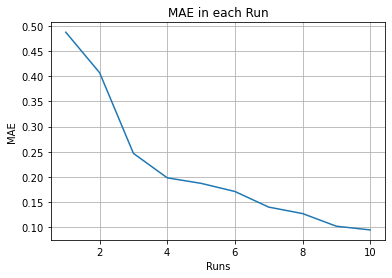

Validation MAE 2NN(WS): 0.216


In [37]:
# Graph to analyse how MAE is fluctuating in every run

import matplotlib.pyplot as plt
plt.title('MAE in each Run')
plt.plot(np.arange(1,11),mae_list_two_ws)
plt.xlabel("Runs")
plt.ylabel("MAE")
plt.grid()
plt.show()

#Mean Absolute Error
val_mae_2_ws = np.mean(mae_list_two_ws)
print("Validation MAE 2NN(WS):",round(val_mae_2_ws,4))

MSE

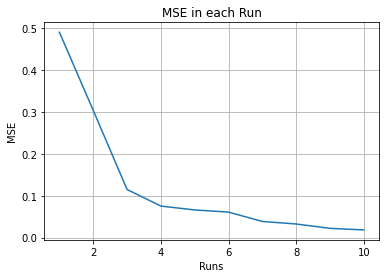

Validation MSE 2NN(WS): 0.1223


In [38]:
import matplotlib.pyplot as plt
plt.title('MSE in each Run')
plt.plot(np.arange(1,11),mse_list_two_ws)
plt.xlabel("Runs")
plt.ylabel("MSE")
plt.grid()
plt.show()

#Root Mean Square Error
val_mse_2_ws = np.mean(mse_list_two_ws)
print("Validation MSE 2NN(WS):",round(val_mse_2_ws,4))

Now we'll check how our model is performing on the unseen data i.e. Test DataSet

TestSet Analysis

In [39]:
#Predicting Test Set Results 
predicted_y_test = sequential_two_ws.predict(
    X_test_original, batch_size=512, verbose=0, steps=None, callbacks=None, max_queue_size=10
  )

test_mae_2NN_WS = mean_absolute_error(predicted_y_test, y_test_original)
test_mse_2NN_WS = mean_squared_error(predicted_y_test, y_test_original)
print("Test MAE 2NN(WS) : ",round(test_mae_2NN_WS,4))
print("Test MSE 2NN(WS) : ", round(test_mse_2NN_WS,4))

Test MAE 2NN(WS) :  0.1231
Test MSE 2NN(WS) :  0.031


### 2 layer NN(VORP)

In this case, VORP is our predictor variable and is splitted from the rest dataset.

In [40]:
#Splitting of independent and dependent variable

X = season_stats.loc[:, season_stats.columns != 'VORP']
y = season_stats.loc[:, season_stats.columns == 'VORP']


display(X)
display(y)

,Year,Pos,Age,G,MP,PER,TS%,3PAr,FTr,ORB%,...,Player_Zach Randolph,Player_Zan Tabak,Player_Zarko Cabarkapa,Player_Zarko Paspalj,Player_Zaza Pachulia,Player_Zeljko Rebraca,Player_Zendon Hamilton,Player_Zoran Dragic,Player_Zoran Planinic,Player_Zydrunas Ilgauskas
0,1980.0,5.0,32.0,82.0,3143.0,25.3,0.639,0.001,0.344,7.2,...,0,0,0,0,0,0,0,0,0,0
1,1980.0,4.0,25.0,67.0,1222.0,11.0,0.511,0.003,0.258,5.4,...,0,0,0,0,0,0,0,0,0,0
2,1980.0,5.0,25.0,75.0,2168.0,19.2,0.571,0.002,0.270,8.2,...,0,0,0,0,0,0,0,0,0,0
3,1980.0,1.0,31.0,80.0,2864.0,15.3,0.574,0.023,0.548,2.3,...,0,0,0,0,0,0,0,0,0,0
4,1980.0,5.0,31.0,26.0,560.0,7.4,0.524,0.000,0.833,6.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,2017.0,4.0,24.0,62.0,1725.0,16.7,0.604,0.002,0.442,8.6,...,0,0,0,0,0,0,0,0,0,0
17932,2017.0,5.0,27.0,51.0,525.0,13.0,0.508,0.006,0.247,9.2,...,0,0,0,0,0,0,0,0,0,0
17933,2017.0,5.0,20.0,19.0,108.0,7.3,0.346,0.000,0.161,10.8,...,0,0,0,0,0,0,0,0,0,0
17934,2017.0,3.0,22.0,44.0,843.0,6.9,0.503,0.448,0.181,1.9,...,0,0,0,0,0,0,0,0,0,0


,VORP
0,6.8
1,0.1
2,3.5
3,1.5
4,0.1
...,...
17931,1.8
17932,-0.1
17933,-0.1
17934,-0.4


Now the same steps get carried for all three models are fit and evaluated on both the predictor variables

#### Train Test Validation Split

In [41]:
#Splitting Trainning Validation and Test Set in the ratio 70:30

X_train_original, X_test_original,y_train_original, y_test_original = train_test_split(X,y, test_size = 0.3, shuffle=True)

print(X.shape)

print("Trainning and Validation Set for X", X_train_original.shape)
print("Trainning and Validation Set for y",y_train_original.shape)
print("Test Set for X",X_test_original.shape)
print("Test Set for y",y_test_original.shape)

(17936, 2767)
Trainning and Validation Set for X (12555, 2767)
Trainning and Validation Set for y (12555, 1)
Test Set for X (5381, 2767)
Test Set for y (5381, 1)


#### Model Trainning with Cross Validation 

In [42]:
#2 layer model

sequential_two_vorp = Sequential()

# Input Layer :
sequential_two_vorp.add(Dense(128, kernel_initializer='normal',input_dim = X_train_original.shape[1], activation='relu'))

# Hidden Layer :
sequential_two_vorp.add(Dense(256, kernel_initializer='normal',activation='relu'))

# Output Layer :
sequential_two_vorp.add(Dense(1, kernel_initializer='normal',activation='linear'))

# Compile the network :
sequential_two_vorp.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])
sequential_two_vorp.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 128)               354304    
                                                                 
 dense_4 (Dense)             (None, 256)               33024     
                                                                 
 dense_5 (Dense)             (None, 1)                 257       
                                                                 
Total params: 387,585
Trainable params: 387,585
Non-trainable params: 0
_________________________________________________________________


In [43]:
mae_list_two_vorp,mse_list_two_vorp = [],[]

#Repeated evaluation experiments to control the uncertainity of the model
for i in range(10): 
  mae_list,mse_list = [],[]  

  #Performing Cross validation with 10 splits
  cv = KFold(n_splits = 10)
  for train_index, test_index in cv.split(X_train_original):
    X_train, X_test = X_train_original.iloc[train_index], X_train_original.iloc[test_index]
    y_train, y_test = y_train_original.iloc[train_index], y_train_original.iloc[test_index]
    
    #Model fitting
    sequential_two_vorp.fit(X_train, y_train, epochs=10, batch_size=512, validation_split = 0, shuffle= True)
    curr_y = sequential_two_vorp.predict(X_test)

    #Calculating the true and predicted values as a list 
    y_true = y_test['VORP'].values
    y_pred = curr_y.tolist()
    
    #Adding the CV Error for every split
    mae_list.append(mean_absolute_error(y_true,y_pred))
    mse_list.append(mean_squared_error(y_true,y_pred))

  #Adding the means to a list for calculating the grand mean
  mae_list_two_vorp.append(np.mean(mae_list))
  mse_list_two_vorp.append(np.mean(mse_list))

Epoch 1/10
23/23 [==============================] - 0s 8ms/step - loss: 164.8490 - mean_squared_error: 164.8490
Epoch 2/10
23/23 [==============================] - 0s 9ms/step - loss: 8.4843 - mean_squared_error: 8.4843
Epoch 3/10
23/23 [==============================] - 0s 9ms/step - loss: 2.0392 - mean_squared_error: 2.0392
Epoch 4/10
23/23 [==============================] - 0s 9ms/step - loss: 1.1901 - mean_squared_error: 1.1901
Epoch 5/10
23/23 [==============================] - 0s 8ms/step - loss: 0.9510 - mean_squared_error: 0.9510
Epoch 6/10
23/23 [==============================] - 0s 8ms/step - loss: 0.8360 - mean_squared_error: 0.8360
Epoch 7/10
23/23 [==============================] - 0s 9ms/step - loss: 0.7127 - mean_squared_error: 0.7127
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.6685 - mean_squared_error: 0.6685
Epoch 9/10
23/23 [==============================] - 0s 9ms/step - loss: 0.5775 - mean_squared_error: 0.5775
Epoch 10/10
23/23 [=====

23/23 [==============================] - 0s 10ms/step - loss: 0.0310 - mean_squared_error: 0.0310
Epoch 2/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1929 - mean_squared_error: 0.1929
Epoch 3/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0364 - mean_squared_error: 0.0364
Epoch 4/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0505 - mean_squared_error: 0.0505
Epoch 5/10
23/23 [==============================] - 0s 9ms/step - loss: 0.2097 - mean_squared_error: 0.2097
Epoch 6/10
23/23 [==============================] - 0s 9ms/step - loss: 0.3874 - mean_squared_error: 0.3874
Epoch 7/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1585 - mean_squared_error: 0.1585
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.2339 - mean_squared_error: 0.2339
Epoch 9/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1091 - mean_squared_error: 0.1091
Epoch 10/10
23/23 [===================

23/23 [==============================] - 0s 9ms/step - loss: 0.0117 - mean_squared_error: 0.0117
Epoch 2/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0130 - mean_squared_error: 0.0130
Epoch 3/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0135 - mean_squared_error: 0.0135
Epoch 4/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0084 - mean_squared_error: 0.0084
Epoch 5/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0128 - mean_squared_error: 0.0128
Epoch 6/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0203 - mean_squared_error: 0.0203
Epoch 7/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0199 - mean_squared_error: 0.0199
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0196 - mean_squared_error: 0.0196
Epoch 9/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0107 - mean_squared_error: 0.0107
Epoch 10/10
23/23 [====================

23/23 [==============================] - 0s 11ms/step - loss: 0.0070 - mean_squared_error: 0.0070
Epoch 2/10
23/23 [==============================] - 0s 12ms/step - loss: 0.0115 - mean_squared_error: 0.0115
Epoch 3/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0410 - mean_squared_error: 0.0410
Epoch 4/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0062 - mean_squared_error: 0.0062
Epoch 5/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0053 - mean_squared_error: 0.0053
Epoch 6/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0071 - mean_squared_error: 0.0071
Epoch 7/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0084 - mean_squared_error: 0.0084
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0094 - mean_squared_error: 0.0094
Epoch 9/10
23/23 [==============================] - 0s 8ms/step - loss: 0.1257 - mean_squared_error: 0.1257
Epoch 10/10
23/23 [==============

23/23 [==============================] - 0s 9ms/step - loss: 0.0037 - mean_squared_error: 0.0037
Epoch 2/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0052 - mean_squared_error: 0.0052
Epoch 3/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0072 - mean_squared_error: 0.0072
Epoch 4/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0041 - mean_squared_error: 0.0041
Epoch 5/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0139 - mean_squared_error: 0.0139
Epoch 6/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0281 - mean_squared_error: 0.0281
Epoch 7/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0053 - mean_squared_error: 0.0053
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0172 - mean_squared_error: 0.0172
Epoch 9/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0176 - mean_squared_error: 0.0176
Epoch 10/10
23/23 [====================

23/23 [==============================] - 0s 9ms/step - loss: 0.0036 - mean_squared_error: 0.0036
Epoch 2/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0035 - mean_squared_error: 0.0035
Epoch 3/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0017 - mean_squared_error: 0.0017
Epoch 4/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0015 - mean_squared_error: 0.0015
Epoch 5/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0055 - mean_squared_error: 0.0055
Epoch 6/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0124 - mean_squared_error: 0.0124
Epoch 7/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0109 - mean_squared_error: 0.0109
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0043 - mean_squared_error: 0.0043
Epoch 9/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0037 - mean_squared_error: 0.0037
Epoch 10/10
23/23 [====================

23/23 [==============================] - 0s 9ms/step - loss: 0.0035 - mean_squared_error: 0.0035
Epoch 2/10
23/23 [==============================] - 0s 13ms/step - loss: 0.0093 - mean_squared_error: 0.0093
Epoch 3/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0059 - mean_squared_error: 0.0059
Epoch 4/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0024 - mean_squared_error: 0.0024
Epoch 5/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0024 - mean_squared_error: 0.0024
Epoch 6/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0044 - mean_squared_error: 0.0044
Epoch 7/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0017 - mean_squared_error: 0.0017
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0052 - mean_squared_error: 0.0052
Epoch 9/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0033 - mean_squared_error: 0.0033
Epoch 10/10
23/23 [===============

#### Error Analysis

MAE

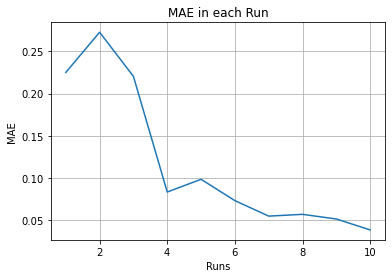

Validation MAE 2NN(VORP): 0.1175


In [44]:
# Graph to analyse how MAE is fluctuating in every run

import matplotlib.pyplot as plt
plt.title('MAE in each Run')
plt.plot(np.arange(1,11),mae_list_two_vorp)
plt.xlabel("Runs")
plt.ylabel("MAE")
plt.grid()
plt.show()

#Mean Absolute Error
val_mae_2_vorp = np.mean(mae_list_two_vorp)
print("Validation MAE 2NN(VORP):",round(val_mae_2_vorp,4))

MSE

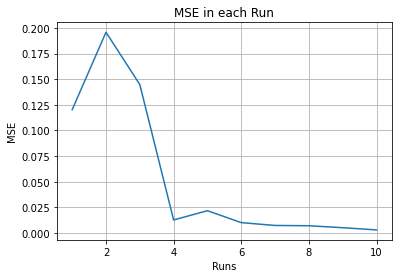

Validation MSE 2NN(VORP): 0.0528


In [45]:
import matplotlib.pyplot as plt
plt.title('MSE in each Run')
plt.plot(np.arange(1,11),mse_list_two_vorp)
plt.xlabel("Runs")
plt.ylabel("MSE")
plt.grid()
plt.show()

#Mean Squared Error
val_mse_2_vorp = np.mean(mse_list_two_vorp)
print("Validation MSE 2NN(VORP):",round(val_mse_2_vorp,4))

TestSet Results

In [46]:
#Predicting Test Set Results 

predicted_y_test = sequential_two_vorp.predict(
    X_test_original, batch_size=512, verbose=0, steps=None, callbacks=None, max_queue_size=10
  )

test_mae_2NN_vorp = mean_absolute_error(predicted_y_test, y_test_original)
test_mse_2NN_vorp = mean_squared_error(predicted_y_test, y_test_original)
print("Test MAE 2NN(VORP) : ",round(test_mae_2NN_vorp,4))
print("Test MSE 2NN(VORP) : ",round(test_mse_2NN_vorp,4))

Test MAE 2NN(VORP) :  0.0355
Test MSE 2NN(VORP) :  0.0027


### 3 layer NN(WS)

In [47]:
#Splitting of independent and dependent variable

X = season_stats.loc[:, season_stats.columns != 'WS']
y = season_stats.loc[:, season_stats.columns == 'WS']

display(X)
display(y)

,Year,Pos,Age,G,MP,PER,TS%,3PAr,FTr,ORB%,...,Player_Zach Randolph,Player_Zan Tabak,Player_Zarko Cabarkapa,Player_Zarko Paspalj,Player_Zaza Pachulia,Player_Zeljko Rebraca,Player_Zendon Hamilton,Player_Zoran Dragic,Player_Zoran Planinic,Player_Zydrunas Ilgauskas
0,1980.0,5.0,32.0,82.0,3143.0,25.3,0.639,0.001,0.344,7.2,...,0,0,0,0,0,0,0,0,0,0
1,1980.0,4.0,25.0,67.0,1222.0,11.0,0.511,0.003,0.258,5.4,...,0,0,0,0,0,0,0,0,0,0
2,1980.0,5.0,25.0,75.0,2168.0,19.2,0.571,0.002,0.270,8.2,...,0,0,0,0,0,0,0,0,0,0
3,1980.0,1.0,31.0,80.0,2864.0,15.3,0.574,0.023,0.548,2.3,...,0,0,0,0,0,0,0,0,0,0
4,1980.0,5.0,31.0,26.0,560.0,7.4,0.524,0.000,0.833,6.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,2017.0,4.0,24.0,62.0,1725.0,16.7,0.604,0.002,0.442,8.6,...,0,0,0,0,0,0,0,0,0,0
17932,2017.0,5.0,27.0,51.0,525.0,13.0,0.508,0.006,0.247,9.2,...,0,0,0,0,0,0,0,0,0,0
17933,2017.0,5.0,20.0,19.0,108.0,7.3,0.346,0.000,0.161,10.8,...,0,0,0,0,0,0,0,0,0,0
17934,2017.0,3.0,22.0,44.0,843.0,6.9,0.503,0.448,0.181,1.9,...,0,0,0,0,0,0,0,0,0,0


,WS
0,14.8
1,2.0
2,7.0
3,8.9
4,0.6
...,...
17931,5.6
17932,1.0
17933,0.0
17934,0.5


#### Train Test Validation Split

In [48]:
#Splitting Trainning Validation and Test Set in the ratio 70:30

X_train_original, X_test_original,y_train_original, y_test_original = train_test_split(X,y, test_size = 0.3, shuffle=True)

print(X.shape)

print("Trainning and Validation Set for X", X_train_original.shape)
print("Trainning and Validation Set for y",y_train_original.shape)
print("Test Set for X",X_test_original.shape)
print("Test Set for y",y_test_original.shape)

(17936, 2767)
Trainning and Validation Set for X (12555, 2767)
Trainning and Validation Set for y (12555, 1)
Test Set for X (5381, 2767)
Test Set for y (5381, 1)


#### Model Trainning with Cross Validation

A 3 layer model is made by introducing a new layer in the middle with the same number of nodes

In [49]:
#3 layer model 

sequential_three_ws = Sequential()

# The Input Layer :
sequential_three_ws.add(Dense(128, kernel_initializer='normal',input_dim = X_train_original.shape[1], activation='relu'))

# The Hidden Layers :
sequential_three_ws.add(Dense(256, kernel_initializer='normal',activation='relu'))
sequential_three_ws.add(Dense(256, kernel_initializer='normal',activation='relu'))

# The Output Layer :
sequential_three_ws.add(Dense(1, kernel_initializer='normal',activation='linear'))

# Compile the network :
sequential_three_ws.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])
sequential_three_ws.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 128)               354304    
                                                                 
 dense_7 (Dense)             (None, 256)               33024     
                                                                 
 dense_8 (Dense)             (None, 256)               65792     
                                                                 
 dense_9 (Dense)             (None, 1)                 257       
                                                                 
Total params: 453,377
Trainable params: 453,377
Non-trainable params: 0
_________________________________________________________________


In [50]:
mae_list_three_ws,mse_list_three_ws = [],[]

#Repeated evaluation experiments to control the uncertainity of the model
for i in range(10): 
  mae_list,mse_list = [],[]  

  #Performing Cross validation with 10 splits
  cv = KFold(n_splits = 10)
  for train_index, test_index in cv.split(X_train_original):
    X_train, X_test = X_train_original.iloc[train_index], X_train_original.iloc[test_index]
    y_train, y_test = y_train_original.iloc[train_index], y_train_original.iloc[test_index]
    
  
    #Model fitting with taken parameters
    sequential_three_ws.fit(X_train, y_train, epochs=10, batch_size=512, validation_split = 0, shuffle= True)
    curr_y = sequential_three_ws.predict(X_test)

    #Calculating the true and predicted values as a list 
    y_true = y_test['WS'].values
    y_pred = curr_y.tolist()
    
    #Adding the CV Error for every split
    mae_list.append(mean_absolute_error(y_true,y_pred))
    mse_list.append(mean_squared_error(y_true,y_pred))

  #Adding the means to a list for calculating the grand mean
  mae_list_three_ws.append(np.mean(mae_list))
  mse_list_three_ws.append(np.mean(mse_list))

Epoch 1/10
23/23 [==============================] - 0s 10ms/step - loss: 372.8792 - mean_squared_error: 372.8792
Epoch 2/10
23/23 [==============================] - 0s 10ms/step - loss: 12.1664 - mean_squared_error: 12.1664
Epoch 3/10
23/23 [==============================] - 0s 10ms/step - loss: 2.7875 - mean_squared_error: 2.7875
Epoch 4/10
23/23 [==============================] - 0s 10ms/step - loss: 1.9091 - mean_squared_error: 1.9091
Epoch 5/10
23/23 [==============================] - 0s 10ms/step - loss: 1.4356 - mean_squared_error: 1.4356
Epoch 6/10
23/23 [==============================] - 0s 9ms/step - loss: 1.0431 - mean_squared_error: 1.0431
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.8877 - mean_squared_error: 0.8877
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.7400 - mean_squared_error: 0.7400
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.6722 - mean_squared_error: 0.6722
Epoch 10/10
23

23/23 [==============================] - 0s 10ms/step - loss: 0.1074 - mean_squared_error: 0.1074
Epoch 2/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0906 - mean_squared_error: 0.0906
Epoch 3/10
23/23 [==============================] - 0s 11ms/step - loss: 0.2000 - mean_squared_error: 0.2000
Epoch 4/10
23/23 [==============================] - 0s 10ms/step - loss: 0.1028 - mean_squared_error: 0.1028
Epoch 5/10
23/23 [==============================] - 0s 9ms/step - loss: 0.2791 - mean_squared_error: 0.2791
Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 0.1748 - mean_squared_error: 0.1748
Epoch 7/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0984 - mean_squared_error: 0.0984
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0884 - mean_squared_error: 0.0884
Epoch 9/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1037 - mean_squared_error: 0.1037
Epoch 10/10
23/23 [=============

23/23 [==============================] - 0s 11ms/step - loss: 0.0600 - mean_squared_error: 0.0600
Epoch 7/10
23/23 [==============================] - 0s 12ms/step - loss: 0.1704 - mean_squared_error: 0.1704
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.1777 - mean_squared_error: 0.1777
Epoch 9/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0687 - mean_squared_error: 0.0687
Epoch 10/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0719 - mean_squared_error: 0.0719
Epoch 1/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0639 - mean_squared_error: 0.0639
Epoch 2/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0894 - mean_squared_error: 0.0894
Epoch 3/10
23/23 [==============================] - 0s 10ms/step - loss: 0.1239 - mean_squared_error: 0.1239
Epoch 4/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0909 - mean_squared_error: 0.0909
Epoch 5/10
23/23 [==============

23/23 [==============================] - 0s 11ms/step - loss: 0.0381 - mean_squared_error: 0.0381
Epoch 5/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0383 - mean_squared_error: 0.0383
Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0867 - mean_squared_error: 0.0867
Epoch 7/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0723 - mean_squared_error: 0.0723
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0614 - mean_squared_error: 0.0614
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0457 - mean_squared_error: 0.0457
Epoch 10/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0578 - mean_squared_error: 0.0578
Epoch 1/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0409 - mean_squared_error: 0.0409
Epoch 2/10
23/23 [==============================] - 0s 10ms/step - loss: 0.1147 - mean_squared_error: 0.1147
Epoch 3/10
23/23 [=============

23/23 [==============================] - 0s 11ms/step - loss: 0.0895 - mean_squared_error: 0.0895
Epoch 4/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0879 - mean_squared_error: 0.0879
Epoch 5/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0654 - mean_squared_error: 0.0654
Epoch 6/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0266 - mean_squared_error: 0.0266
Epoch 7/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0289 - mean_squared_error: 0.0289
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0365 - mean_squared_error: 0.0365
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0215 - mean_squared_error: 0.0215
Epoch 10/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0216 - mean_squared_error: 0.0216
Epoch 1/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0257 - mean_squared_error: 0.0257
Epoch 2/10
23/23 [============

23/23 [==============================] - 0s 11ms/step - loss: 0.0195 - mean_squared_error: 0.0195
Epoch 3/10
23/23 [==============================] - 0s 12ms/step - loss: 0.0186 - mean_squared_error: 0.0186
Epoch 4/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0241 - mean_squared_error: 0.0241
Epoch 5/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0458 - mean_squared_error: 0.0458
Epoch 6/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0621 - mean_squared_error: 0.0621
Epoch 7/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0299 - mean_squared_error: 0.0299
Epoch 8/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0271 - mean_squared_error: 0.0271
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0292 - mean_squared_error: 0.0292
Epoch 10/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0208 - mean_squared_error: 0.0208
Epoch 1/10
23/23 [============

23/23 [==============================] - 0s 10ms/step - loss: 0.0176 - mean_squared_error: 0.0176
Epoch 2/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0420 - mean_squared_error: 0.0420
Epoch 3/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0451 - mean_squared_error: 0.0451
Epoch 4/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0339 - mean_squared_error: 0.0339
Epoch 5/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0386 - mean_squared_error: 0.0386
Epoch 6/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0331 - mean_squared_error: 0.0331
Epoch 7/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0330 - mean_squared_error: 0.0330
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0302 - mean_squared_error: 0.0302
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0111 - mean_squared_error: 0.0111
Epoch 10/10
23/23 [============

23/23 [==============================] - 0s 11ms/step - loss: 0.0152 - mean_squared_error: 0.0152
Epoch 2/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0190 - mean_squared_error: 0.0190
Epoch 3/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0186 - mean_squared_error: 0.0186
Epoch 4/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0092 - mean_squared_error: 0.0092
Epoch 5/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0355 - mean_squared_error: 0.0355
Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0115 - mean_squared_error: 0.0115
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0311 - mean_squared_error: 0.0311
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0320 - mean_squared_error: 0.0320
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0293 - mean_squared_error: 0.0293
Epoch 10/10
23/23 [===========

#### Error Analysis

MAE

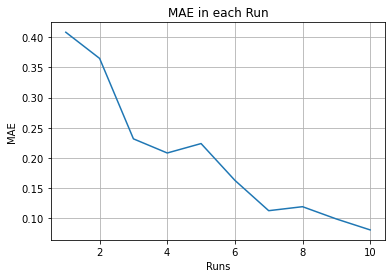

Validation MAE 3NN(WS): 0.2012


In [51]:
# Graph to analyse how MAE is fluctuating in every run

plt.title('MAE in each Run')
plt.plot(np.arange(1,11),mae_list_three_ws)
plt.xlabel("Runs")
plt.ylabel("MAE")
plt.grid()
plt.show()

#Mean Absolute Error
val_mae_3_ws = np.mean(mae_list_three_ws)
print("Validation MAE 3NN(WS):",round(val_mae_3_ws,4))

MSE

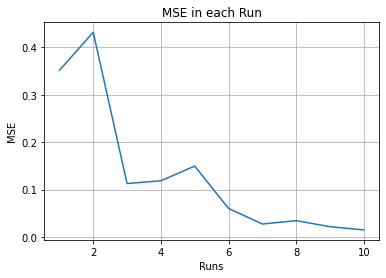

Validation MSE 3NN(WS): 0.1323


In [52]:
# Graph to analyse how MSE is fluctuating in every run

plt.title('MSE in each Run')
plt.plot(np.arange(1,11),mse_list_three_ws)
plt.xlabel("Runs")
plt.ylabel("MSE")
plt.grid()
plt.show()

#Root Mean Square Error
val_mse_3_ws = np.mean(mse_list_three_ws)
print("Validation MSE 3NN(WS):",round(val_mse_3_ws,4))

TestSet Results

In [53]:
predicted_y_test = sequential_three_ws.predict(
    X_test_original, batch_size=512, verbose=0, steps=None, callbacks=None, max_queue_size=10
  )

test_mae_3NN_WS = mean_absolute_error(predicted_y_test, y_test_original)
test_mse_3NN_WS = mean_squared_error(predicted_y_test, y_test_original)
print("Test MAE 3NN(WS) : ",round(test_mae_3NN_WS,4))
print("Test MSE 3NN(WS) : ", round(test_mse_3NN_WS,4))

Test MAE 3NN(WS) :  0.1264
Test MSE 3NN(WS) :  0.0337


### 3 Layer NN(VORP)

In [54]:
#Splitting of independent and dependent variable

X = season_stats.loc[:, season_stats.columns != 'VORP']
y = season_stats.loc[:, season_stats.columns == 'VORP']


display(X)
display(y)

,Year,Pos,Age,G,MP,PER,TS%,3PAr,FTr,ORB%,...,Player_Zach Randolph,Player_Zan Tabak,Player_Zarko Cabarkapa,Player_Zarko Paspalj,Player_Zaza Pachulia,Player_Zeljko Rebraca,Player_Zendon Hamilton,Player_Zoran Dragic,Player_Zoran Planinic,Player_Zydrunas Ilgauskas
0,1980.0,5.0,32.0,82.0,3143.0,25.3,0.639,0.001,0.344,7.2,...,0,0,0,0,0,0,0,0,0,0
1,1980.0,4.0,25.0,67.0,1222.0,11.0,0.511,0.003,0.258,5.4,...,0,0,0,0,0,0,0,0,0,0
2,1980.0,5.0,25.0,75.0,2168.0,19.2,0.571,0.002,0.270,8.2,...,0,0,0,0,0,0,0,0,0,0
3,1980.0,1.0,31.0,80.0,2864.0,15.3,0.574,0.023,0.548,2.3,...,0,0,0,0,0,0,0,0,0,0
4,1980.0,5.0,31.0,26.0,560.0,7.4,0.524,0.000,0.833,6.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,2017.0,4.0,24.0,62.0,1725.0,16.7,0.604,0.002,0.442,8.6,...,0,0,0,0,0,0,0,0,0,0
17932,2017.0,5.0,27.0,51.0,525.0,13.0,0.508,0.006,0.247,9.2,...,0,0,0,0,0,0,0,0,0,0
17933,2017.0,5.0,20.0,19.0,108.0,7.3,0.346,0.000,0.161,10.8,...,0,0,0,0,0,0,0,0,0,0
17934,2017.0,3.0,22.0,44.0,843.0,6.9,0.503,0.448,0.181,1.9,...,0,0,0,0,0,0,0,0,0,0


,VORP
0,6.8
1,0.1
2,3.5
3,1.5
4,0.1
...,...
17931,1.8
17932,-0.1
17933,-0.1
17934,-0.4


#### Train Test Validation Split

In [55]:
#Splitting Trainning Validation and Test Set in the ratio 70:30

X_train_original, X_test_original,y_train_original, y_test_original = train_test_split(X,y, test_size = 0.3, shuffle=True)

print(X.shape)

print("Trainning and Validation Set for X", X_train_original.shape)
print("Trainning and Validation Set for y",y_train_original.shape)
print("Test Set for X",X_test_original.shape)
print("Test Set for y",y_test_original.shape)

(17936, 2767)
Trainning and Validation Set for X (12555, 2767)
Trainning and Validation Set for y (12555, 1)
Test Set for X (5381, 2767)
Test Set for y (5381, 1)


#### Model Trainning with Cross Validation

In [56]:
#3 layer model 

sequential_three_vorp = Sequential()

# The Input Layer :
sequential_three_vorp.add(Dense(128, kernel_initializer='normal',input_dim = X_train_original.shape[1], activation='relu'))

# The Hidden Layers :
sequential_three_vorp.add(Dense(256, kernel_initializer='normal',activation='relu'))
sequential_three_vorp.add(Dense(256, kernel_initializer='normal',activation='relu'))

# The Output Layer :
sequential_three_vorp.add(Dense(1, kernel_initializer='normal',activation='linear'))

# Compile the network :
sequential_three_vorp.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])
sequential_three_vorp.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 128)               354304    
                                                                 
 dense_11 (Dense)            (None, 256)               33024     
                                                                 
 dense_12 (Dense)            (None, 256)               65792     
                                                                 
 dense_13 (Dense)            (None, 1)                 257       
                                                                 
Total params: 453,377
Trainable params: 453,377
Non-trainable params: 0
_________________________________________________________________


In [57]:
mae_list_three_vorp,mse_list_three_vorp = [],[]

#Repeated evaluation experiments to control the uncertainity of the model
for i in range(10): 
  mae_list,mse_list = [],[]  

  #Performing Cross validation with 10 splits
  cv = KFold(n_splits = 10)
  for train_index, test_index in cv.split(X_train_original):
    X_train, X_test = X_train_original.iloc[train_index], X_train_original.iloc[test_index]
    y_train, y_test = y_train_original.iloc[train_index], y_train_original.iloc[test_index]
    
    #Model fitting
    sequential_three_vorp.fit(X_train, y_train, epochs=10, batch_size=512, validation_split = 0, shuffle= True)
    curr_y = sequential_three_vorp.predict(X_test)

    #Calculating the true and predicted values as a list 
    y_true = y_test['VORP'].values
    y_pred = curr_y.tolist()
    
    #Adding the CV Error for every split
    mae_list.append(mean_absolute_error(y_true,y_pred))
    mse_list.append(mean_squared_error(y_true,y_pred))

  #Adding the means to a list for calculating the grand mean
  mae_list_three_vorp.append(np.mean(mae_list))
  mse_list_three_vorp.append(np.mean(mse_list))

Epoch 1/10
23/23 [==============================] - 1s 10ms/step - loss: 155.3387 - mean_squared_error: 155.3387
Epoch 2/10
23/23 [==============================] - 0s 10ms/step - loss: 5.1890 - mean_squared_error: 5.1890
Epoch 3/10
23/23 [==============================] - 0s 10ms/step - loss: 0.8022 - mean_squared_error: 0.8022
Epoch 4/10
23/23 [==============================] - 0s 10ms/step - loss: 0.6058 - mean_squared_error: 0.6058
Epoch 5/10
23/23 [==============================] - 0s 9ms/step - loss: 0.5501 - mean_squared_error: 0.5501
Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 0.5050 - mean_squared_error: 0.5050
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.4674 - mean_squared_error: 0.4674
Epoch 8/10
23/23 [==============================] - 0s 9ms/step - loss: 0.4405 - mean_squared_error: 0.4405
Epoch 9/10
23/23 [==============================] - 0s 9ms/step - loss: 0.4154 - mean_squared_error: 0.4154
Epoch 10/10
23/23 

Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0327 - mean_squared_error: 0.0327
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0346 - mean_squared_error: 0.0346
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0322 - mean_squared_error: 0.0322
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0412 - mean_squared_error: 0.0412
Epoch 10/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0844 - mean_squared_error: 0.0844
Epoch 1/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0349 - mean_squared_error: 0.0349
Epoch 2/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0279 - mean_squared_error: 0.0279
Epoch 3/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0300 - mean_squared_error: 0.0300
Epoch 4/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0324 - mean_squared_error: 0.0324
Epoch 5/10
23/23 [=====

23/23 [==============================] - 0s 11ms/step - loss: 0.0111 - mean_squared_error: 0.0111
Epoch 6/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0092 - mean_squared_error: 0.0092
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0495 - mean_squared_error: 0.0495
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0222 - mean_squared_error: 0.0222
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0091 - mean_squared_error: 0.0091
Epoch 10/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0103 - mean_squared_error: 0.0103
Epoch 1/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0568 - mean_squared_error: 0.0568
Epoch 2/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0357 - mean_squared_error: 0.0357
Epoch 3/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0345 - mean_squared_error: 0.0345
Epoch 4/10
23/23 [==============

23/23 [==============================] - 0s 10ms/step - loss: 0.0085 - mean_squared_error: 0.0085
Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0217 - mean_squared_error: 0.0217
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0107 - mean_squared_error: 0.0107
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0087 - mean_squared_error: 0.0087
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0163 - mean_squared_error: 0.0163
Epoch 10/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0048 - mean_squared_error: 0.0048
Epoch 1/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0053 - mean_squared_error: 0.0053
Epoch 2/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0039 - mean_squared_error: 0.0039
Epoch 3/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0126 - mean_squared_error: 0.0126
Epoch 4/10
23/23 [=============

23/23 [==============================] - 0s 9ms/step - loss: 0.0082 - mean_squared_error: 0.0082
Epoch 4/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0046 - mean_squared_error: 0.0046
Epoch 5/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0023 - mean_squared_error: 0.0023
Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0060 - mean_squared_error: 0.0060
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0040 - mean_squared_error: 0.0040
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0032 - mean_squared_error: 0.0032
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0031 - mean_squared_error: 0.0031
Epoch 10/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0059 - mean_squared_error: 0.0059
Epoch 1/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0052 - mean_squared_error: 0.0052
Epoch 2/10
23/23 [================

23/23 [==============================] - 0s 9ms/step - loss: 0.0028 - mean_squared_error: 0.0028
Epoch 4/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0027 - mean_squared_error: 0.0027
Epoch 5/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0021 - mean_squared_error: 0.0021
Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0023 - mean_squared_error: 0.0023
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0035 - mean_squared_error: 0.0035
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0026 - mean_squared_error: 0.0026
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0078 - mean_squared_error: 0.0078
Epoch 10/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0029 - mean_squared_error: 0.0029
Epoch 1/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0031 - mean_squared_error: 0.0031
Epoch 2/10
23/23 [===============

23/23 [==============================] - 0s 10ms/step - loss: 0.0046 - mean_squared_error: 0.0046
Epoch 4/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0041 - mean_squared_error: 0.0041
Epoch 5/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0022 - mean_squared_error: 0.0022
Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0013 - mean_squared_error: 0.0013
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0011 - mean_squared_error: 0.0011
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0013 - mean_squared_error: 0.0013
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0013 - mean_squared_error: 0.0013
Epoch 10/10
23/23 [==============================] - 0s 8ms/step - loss: 0.0044 - mean_squared_error: 0.0044
Epoch 1/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0029 - mean_squared_error: 0.0029
Epoch 2/10
23/23 [=============

23/23 [==============================] - 0s 9ms/step - loss: 0.0025 - mean_squared_error: 0.0025
Epoch 2/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0026 - mean_squared_error: 0.0026
Epoch 3/10
23/23 [==============================] - 0s 9ms/step - loss: 0.0045 - mean_squared_error: 0.0045
Epoch 4/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0019 - mean_squared_error: 0.0019
Epoch 5/10
23/23 [==============================] - 0s 11ms/step - loss: 0.0025 - mean_squared_error: 0.0025 0s - loss: 0.0025 - mean_squared_error: 0.00
Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0010 - mean_squared_error: 0.0010 
Epoch 7/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0023 - mean_squared_error: 0.0023
Epoch 8/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0011 - mean_squared_error: 0.0011
Epoch 9/10
23/23 [==============================] - 0s 10ms/step - loss: 0.0014 - mean_squared_e

#### Error Analysis

MAE

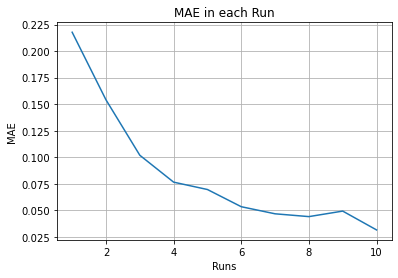

Validation MAE 3NN(VORP): 0.0846


In [58]:
# Graph to analyse how MAE is fluctuating in every run
plt.title('MAE in each Run')
plt.plot(np.arange(1,11),mae_list_three_vorp)
plt.xlabel("Runs")
plt.ylabel("MAE")
plt.grid()
plt.show()

#Mean Absolute Error
val_mae_3_vorp = np.mean(mae_list_three_vorp)
print("Validation MAE 3NN(VORP):",round(val_mae_3_vorp,4))

MSE

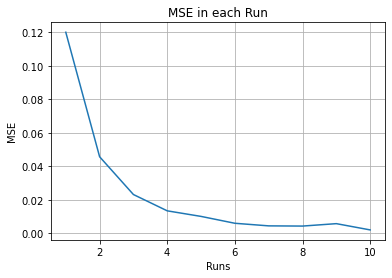

Validation MSE 3NN(VORP): 0.0234


In [59]:
# Graph to analyse how MSE is fluctuating in every run
plt.title('MSE in each Run')
plt.plot(np.arange(1,11),mse_list_three_vorp)
plt.xlabel("Runs")
plt.ylabel("MSE")
plt.grid()
plt.show()

#Mean Squared Error
val_mse_3_vorp = np.mean(mse_list_three_vorp)
print("Validation MSE 3NN(VORP):",round(val_mse_3_vorp,4))

TestSet Results

In [60]:
#Predicting Test Set Results 

predicted_y_test = sequential_three_vorp.predict(
    X_test_original, batch_size=512, verbose=0, steps=None, callbacks=None, max_queue_size=10
  )

test_mae_3NN_vorp = mean_absolute_error(predicted_y_test, y_test_original)
test_mse_3NN_vorp = mean_squared_error(predicted_y_test, y_test_original)
print("Test MAE 3NN(VORP) : ",round(test_mae_3NN_vorp,4))
print("Test MSE 3NN(VORP) : ",round(test_mse_3NN_vorp,4))

Test MAE 3NN(VORP) :  0.0354
Test MSE 3NN(VORP) :  0.0022


### 3 Layer NN with more Nodes (WS)

In [61]:
#Splitting of independent and dependent variable

X = season_stats.loc[:, season_stats.columns != 'WS']
y = season_stats.loc[:, season_stats.columns == 'WS']

display(X)
display(y)

,Year,Pos,Age,G,MP,PER,TS%,3PAr,FTr,ORB%,...,Player_Zach Randolph,Player_Zan Tabak,Player_Zarko Cabarkapa,Player_Zarko Paspalj,Player_Zaza Pachulia,Player_Zeljko Rebraca,Player_Zendon Hamilton,Player_Zoran Dragic,Player_Zoran Planinic,Player_Zydrunas Ilgauskas
0,1980.0,5.0,32.0,82.0,3143.0,25.3,0.639,0.001,0.344,7.2,...,0,0,0,0,0,0,0,0,0,0
1,1980.0,4.0,25.0,67.0,1222.0,11.0,0.511,0.003,0.258,5.4,...,0,0,0,0,0,0,0,0,0,0
2,1980.0,5.0,25.0,75.0,2168.0,19.2,0.571,0.002,0.270,8.2,...,0,0,0,0,0,0,0,0,0,0
3,1980.0,1.0,31.0,80.0,2864.0,15.3,0.574,0.023,0.548,2.3,...,0,0,0,0,0,0,0,0,0,0
4,1980.0,5.0,31.0,26.0,560.0,7.4,0.524,0.000,0.833,6.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,2017.0,4.0,24.0,62.0,1725.0,16.7,0.604,0.002,0.442,8.6,...,0,0,0,0,0,0,0,0,0,0
17932,2017.0,5.0,27.0,51.0,525.0,13.0,0.508,0.006,0.247,9.2,...,0,0,0,0,0,0,0,0,0,0
17933,2017.0,5.0,20.0,19.0,108.0,7.3,0.346,0.000,0.161,10.8,...,0,0,0,0,0,0,0,0,0,0
17934,2017.0,3.0,22.0,44.0,843.0,6.9,0.503,0.448,0.181,1.9,...,0,0,0,0,0,0,0,0,0,0


,WS
0,14.8
1,2.0
2,7.0
3,8.9
4,0.6
...,...
17931,5.6
17932,1.0
17933,0.0
17934,0.5



#### Train Test Validation Split

In [62]:
#Splitting Trainning Validation and Test Set in the ratio 70:30

X_train_original, X_test_original,y_train_original, y_test_original = train_test_split(X,y, test_size = 0.3, shuffle=True)

print(X.shape)

print("Trainning and Validation Set for X", X_train_original.shape)
print("Trainning and Validation Set for y",y_train_original.shape)
print("Test Set for X",X_test_original.shape)
print("Test Set for y",y_test_original.shape)

(17936, 2767)
Trainning and Validation Set for X (12555, 2767)
Trainning and Validation Set for y (12555, 1)
Test Set for X (5381, 2767)
Test Set for y (5381, 1)


#### Model Trainning with Cross Validation

A 3 Layer model is introduced with increased number of nodes in the middle layers to obtain a 3 layer model with additional nodes

In [63]:
#3 layer model with increased nodes 
sequential_three_increased_ws  = Sequential()

# The Input Layer :
sequential_three_increased_ws.add(Dense(128, kernel_initializer='normal',input_dim = X_train.shape[1], activation='relu'))

# The Hidden Layers :
sequential_three_increased_ws.add(Dense(512, kernel_initializer='normal',activation='relu'))
sequential_three_increased_ws.add(Dense(512, kernel_initializer='normal',activation='relu'))

# The Output Layer :
sequential_three_increased_ws.add(Dense(1, kernel_initializer='normal',activation='linear'))

# Compile the network :
sequential_three_increased_ws.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])
sequential_three_increased_ws.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_14 (Dense)            (None, 128)               354304    
                                                                 
 dense_15 (Dense)            (None, 512)               66048     
                                                                 
 dense_16 (Dense)            (None, 512)               262656    
                                                                 
 dense_17 (Dense)            (None, 1)                 513       
                                                                 
Total params: 683,521
Trainable params: 683,521
Non-trainable params: 0
_________________________________________________________________


In [64]:
mae_list_threeinc_ws,mse_list_threeinc_ws = [],[]

#Repeated evaluation experiments to control the uncertainity of the model
for i in range(10): 
  mae_list,mse_list = [],[]  

  #Performing Cross validation with 10 splits
  cv = KFold(n_splits = 10)
  for train_index, test_index in cv.split(X_train_original):
    X_train, X_test = X_train_original.iloc[train_index], X_train_original.iloc[test_index]
    y_train, y_test = y_train_original.iloc[train_index], y_train_original.iloc[test_index]
    
  
    #Model fitting with taken parameters
    sequential_three_increased_ws.fit(X_train, y_train, epochs=10, batch_size=512, validation_split = 0, shuffle= True)
    curr_y = sequential_three_increased_ws.predict(X_test)

    #Calculating the true and predicted values as a list 
    y_true = y_test['WS'].values
    y_pred = curr_y.tolist()
    
    #Adding the CV Error for every split
    mae_list.append(mean_absolute_error(y_true,y_pred))
    mse_list.append(mean_squared_error(y_true,y_pred))

  #Adding the means to a list for calculating the grand mean
  mae_list_threeinc_ws.append(np.mean(mae_list))
  mse_list_threeinc_ws.append(np.mean(mse_list))

Epoch 1/10
23/23 [==============================] - 1s 14ms/step - loss: 3853.7332 - mean_squared_error: 3853.7332
Epoch 2/10
23/23 [==============================] - 0s 14ms/step - loss: 46.6137 - mean_squared_error: 46.6137
Epoch 3/10
23/23 [==============================] - 0s 13ms/step - loss: 4.7856 - mean_squared_error: 4.7856
Epoch 4/10
23/23 [==============================] - 0s 14ms/step - loss: 2.2966 - mean_squared_error: 2.2966
Epoch 5/10
23/23 [==============================] - 0s 14ms/step - loss: 1.7592 - mean_squared_error: 1.7592
Epoch 6/10
23/23 [==============================] - 0s 14ms/step - loss: 1.5219 - mean_squared_error: 1.5219
Epoch 7/10
23/23 [==============================] - 0s 14ms/step - loss: 1.3447 - mean_squared_error: 1.3447
Epoch 8/10
23/23 [==============================] - 0s 14ms/step - loss: 1.2211 - mean_squared_error: 1.2211
Epoch 9/10
23/23 [==============================] - 0s 14ms/step - loss: 1.0768 - mean_squared_error: 1.0768
Epoch 10/10

23/23 [==============================] - 0s 14ms/step - loss: 0.1846 - mean_squared_error: 0.1846
Epoch 1/10
23/23 [==============================] - 0s 13ms/step - loss: 0.1830 - mean_squared_error: 0.1830
Epoch 2/10
23/23 [==============================] - 0s 14ms/step - loss: 0.2204 - mean_squared_error: 0.2204
Epoch 3/10
23/23 [==============================] - 0s 15ms/step - loss: 0.3109 - mean_squared_error: 0.3109
Epoch 4/10
23/23 [==============================] - 0s 14ms/step - loss: 0.1780 - mean_squared_error: 0.1780
Epoch 5/10
23/23 [==============================] - 0s 14ms/step - loss: 0.1937 - mean_squared_error: 0.1937
Epoch 6/10
23/23 [==============================] - 0s 15ms/step - loss: 0.3262 - mean_squared_error: 0.3262
Epoch 7/10
23/23 [==============================] - 0s 17ms/step - loss: 0.4432 - mean_squared_error: 0.4432
Epoch 8/10
23/23 [==============================] - 0s 16ms/step - loss: 0.1764 - mean_squared_error: 0.1764
Epoch 9/10
23/23 [============

23/23 [==============================] - 0s 15ms/step - loss: 0.1172 - mean_squared_error: 0.1172
Epoch 10/10
23/23 [==============================] - 0s 13ms/step - loss: 0.1030 - mean_squared_error: 0.1030
Epoch 1/10
23/23 [==============================] - 0s 14ms/step - loss: 0.1262 - mean_squared_error: 0.1262
Epoch 2/10
23/23 [==============================] - 0s 13ms/step - loss: 0.2800 - mean_squared_error: 0.2800
Epoch 3/10
23/23 [==============================] - 0s 15ms/step - loss: 0.1724 - mean_squared_error: 0.1724
Epoch 4/10
23/23 [==============================] - 0s 14ms/step - loss: 0.1366 - mean_squared_error: 0.1366
Epoch 5/10
23/23 [==============================] - 0s 14ms/step - loss: 0.1931 - mean_squared_error: 0.1931
Epoch 6/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0960 - mean_squared_error: 0.0960
Epoch 7/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0930 - mean_squared_error: 0.0930
Epoch 8/10
23/23 [===========

23/23 [==============================] - 0s 15ms/step - loss: 0.1165 - mean_squared_error: 0.1165
Epoch 9/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0731 - mean_squared_error: 0.0731
Epoch 10/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0748 - mean_squared_error: 0.0748
Epoch 1/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0573 - mean_squared_error: 0.0573
Epoch 2/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0733 - mean_squared_error: 0.0733
Epoch 3/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0603 - mean_squared_error: 0.0603
Epoch 4/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0529 - mean_squared_error: 0.0529
Epoch 5/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0765 - mean_squared_error: 0.0765
Epoch 6/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0604 - mean_squared_error: 0.0604
Epoch 7/10
23/23 [===========

23/23 [==============================] - 0s 14ms/step - loss: 0.0307 - mean_squared_error: 0.0307
Epoch 8/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0359 - mean_squared_error: 0.0359
Epoch 9/10
23/23 [==============================] - 0s 13ms/step - loss: 0.0278 - mean_squared_error: 0.0278
Epoch 10/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0421 - mean_squared_error: 0.0421
Epoch 1/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0325 - mean_squared_error: 0.0325
Epoch 2/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0541 - mean_squared_error: 0.0541
Epoch 3/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0353 - mean_squared_error: 0.0353
Epoch 4/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0348 - mean_squared_error: 0.0348
Epoch 5/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0347 - mean_squared_error: 0.0347
Epoch 6/10
23/23 [===========

23/23 [==============================] - 0s 14ms/step - loss: 0.0703 - mean_squared_error: 0.0703
Epoch 7/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0402 - mean_squared_error: 0.0402
Epoch 8/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0340 - mean_squared_error: 0.0340
Epoch 9/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0283 - mean_squared_error: 0.0283
Epoch 10/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0227 - mean_squared_error: 0.0227
Epoch 1/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0214 - mean_squared_error: 0.0214
Epoch 2/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0202 - mean_squared_error: 0.0202
Epoch 3/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0177 - mean_squared_error: 0.0177
Epoch 4/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0280 - mean_squared_error: 0.0280
Epoch 5/10
23/23 [===========

23/23 [==============================] - 0s 16ms/step - loss: 0.0122 - mean_squared_error: 0.0122
Epoch 7/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0132 - mean_squared_error: 0.0132
Epoch 8/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0125 - mean_squared_error: 0.0125
Epoch 9/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0141 - mean_squared_error: 0.0141
Epoch 10/10
23/23 [==============================] - 0s 18ms/step - loss: 0.0120 - mean_squared_error: 0.0120
Epoch 1/10
23/23 [==============================] - 0s 17ms/step - loss: 0.0104 - mean_squared_error: 0.0104
Epoch 2/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0250 - mean_squared_error: 0.0250
Epoch 3/10
23/23 [==============================] - 0s 18ms/step - loss: 0.0296 - mean_squared_error: 0.0296
Epoch 4/10
23/23 [==============================] - 0s 21ms/step - loss: 0.0409 - mean_squared_error: 0.0409
Epoch 5/10
23/23 [===========

#### Error Analysis

MAE

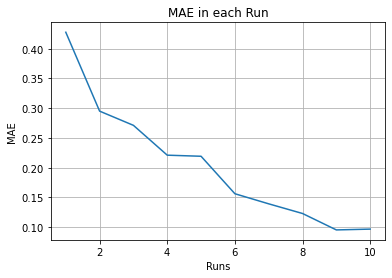

Validation MAE 3NN Increased(WS): 0.2045


In [65]:
# Graph to analyse how MAE is fluctuating in every run

plt.title('MAE in each Run')
plt.plot(np.arange(1,11),mae_list_threeinc_ws)
plt.xlabel("Runs")
plt.ylabel("MAE")
plt.grid()
plt.show()

#Mean Absolute Error
val_mae_3inc_ws = np.mean(mae_list_threeinc_ws)
print("Validation MAE 3NN Increased(WS):",round(val_mae_3inc_ws,4))

MSE

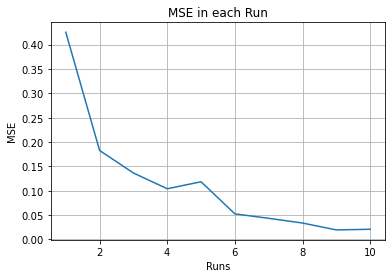

Validation MSE 3NN Increased(WS): 0.1136


In [66]:
# Graph to analyse how MSE is fluctuating in every run

plt.title('MSE in each Run')
plt.plot(np.arange(1,11),mse_list_threeinc_ws)
plt.xlabel("Runs")
plt.ylabel("MSE")
plt.grid()
plt.show()

#Root Mean Square Error
val_mse_3inc_ws = np.mean(mse_list_threeinc_ws)
print("Validation MSE 3NN Increased(WS):",round(val_mse_3inc_ws,4))

TestSet Results

In [67]:
predicted_y_test = sequential_three_increased_ws.predict(
    X_test_original, batch_size=512, verbose=0, steps=None, callbacks=None, max_queue_size=10
  )

test_mae_3NNinc_WS = mean_absolute_error(predicted_y_test, y_test_original)
test_mse_3NNinc_WS = mean_squared_error(predicted_y_test, y_test_original)
print("Test MAE 3NN Increased(WS) : ",round(test_mae_3NNinc_WS,4))
print("Test MSE 3NN Increased(WS) : ", round(test_mse_3NNinc_WS,4))

Test MAE 3NN Increased(WS) :  0.1373
Test MSE 3NN Increased(WS) :  0.0403


### 3 Layer NN with more Nodes(VORP)

In [68]:
#Splitting of independent and dependent variable

X = season_stats.loc[:, season_stats.columns != 'VORP']
y = season_stats.loc[:, season_stats.columns == 'VORP']

display(X)
display(y)

,Year,Pos,Age,G,MP,PER,TS%,3PAr,FTr,ORB%,...,Player_Zach Randolph,Player_Zan Tabak,Player_Zarko Cabarkapa,Player_Zarko Paspalj,Player_Zaza Pachulia,Player_Zeljko Rebraca,Player_Zendon Hamilton,Player_Zoran Dragic,Player_Zoran Planinic,Player_Zydrunas Ilgauskas
0,1980.0,5.0,32.0,82.0,3143.0,25.3,0.639,0.001,0.344,7.2,...,0,0,0,0,0,0,0,0,0,0
1,1980.0,4.0,25.0,67.0,1222.0,11.0,0.511,0.003,0.258,5.4,...,0,0,0,0,0,0,0,0,0,0
2,1980.0,5.0,25.0,75.0,2168.0,19.2,0.571,0.002,0.270,8.2,...,0,0,0,0,0,0,0,0,0,0
3,1980.0,1.0,31.0,80.0,2864.0,15.3,0.574,0.023,0.548,2.3,...,0,0,0,0,0,0,0,0,0,0
4,1980.0,5.0,31.0,26.0,560.0,7.4,0.524,0.000,0.833,6.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,2017.0,4.0,24.0,62.0,1725.0,16.7,0.604,0.002,0.442,8.6,...,0,0,0,0,0,0,0,0,0,0
17932,2017.0,5.0,27.0,51.0,525.0,13.0,0.508,0.006,0.247,9.2,...,0,0,0,0,0,0,0,0,0,0
17933,2017.0,5.0,20.0,19.0,108.0,7.3,0.346,0.000,0.161,10.8,...,0,0,0,0,0,0,0,0,0,0
17934,2017.0,3.0,22.0,44.0,843.0,6.9,0.503,0.448,0.181,1.9,...,0,0,0,0,0,0,0,0,0,0


,VORP
0,6.8
1,0.1
2,3.5
3,1.5
4,0.1
...,...
17931,1.8
17932,-0.1
17933,-0.1
17934,-0.4


#### Train Test Validation Split

In [69]:
#Splitting Trainning Validation and Test Set in the ratio 70:30

X_train_original, X_test_original,y_train_original, y_test_original = train_test_split(X,y, test_size = 0.3, shuffle=True)

print(X.shape)

print("Trainning and Validation Set for X", X_train_original.shape)
print("Trainning and Validation Set for y",y_train_original.shape)
print("Test Set for X",X_test_original.shape)
print("Test Set for y",y_test_original.shape)

(17936, 2767)
Trainning and Validation Set for X (12555, 2767)
Trainning and Validation Set for y (12555, 1)
Test Set for X (5381, 2767)
Test Set for y (5381, 1)


#### Model Trainning with Cross Validation

In [70]:
#3 layer model 

sequential_three_increased_vorp  = Sequential()

# The Input Layer :
sequential_three_increased_vorp.add(Dense(128, kernel_initializer='normal',input_dim = X_train_original.shape[1], activation='relu'))

# The Hidden Layers :
sequential_three_increased_vorp.add(Dense(512, kernel_initializer='normal',activation='relu'))
sequential_three_increased_vorp.add(Dense(512, kernel_initializer='normal',activation='relu'))

# The Output Layer :
sequential_three_increased_vorp.add(Dense(1, kernel_initializer='normal',activation='linear'))

# Compile the network :
sequential_three_increased_vorp.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])
sequential_three_increased_vorp.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 128)               354304    
                                                                 
 dense_19 (Dense)            (None, 512)               66048     
                                                                 
 dense_20 (Dense)            (None, 512)               262656    
                                                                 
 dense_21 (Dense)            (None, 1)                 513       
                                                                 
Total params: 683,521
Trainable params: 683,521
Non-trainable params: 0
_________________________________________________________________


In [71]:
mae_list_threeinc_vorp,mse_list_threeinc_vorp = [],[]

#Repeated evaluation experiments to control the uncertainity of the model
for i in range(10): 
  mae_list,mse_list = [],[]  

  #Performing Cross validation with 10 splits
  cv = KFold(n_splits = 10)
  for train_index, test_index in cv.split(X_train_original):
    X_train, X_test = X_train_original.iloc[train_index], X_train_original.iloc[test_index]
    y_train, y_test = y_train_original.iloc[train_index], y_train_original.iloc[test_index]
    
    #Model fitting
    sequential_three_increased_vorp.fit(X_train, y_train, epochs=10, batch_size=512, validation_split = 0, shuffle= True)
    curr_y = sequential_three_increased_vorp.predict(X_test)

    #Calculating the true and predicted values as a list 
    y_true = y_test['VORP'].values
    y_pred = curr_y.tolist()
    
    #Adding the CV Error for every split
    mae_list.append(mean_absolute_error(y_true,y_pred))
    mse_list.append(mean_squared_error(y_true,y_pred))

  #Adding the means to a list for calculating the grand mean
  mae_list_threeinc_vorp.append(np.mean(mae_list))
  mse_list_threeinc_vorp.append(np.mean(mse_list))

Epoch 1/10
23/23 [==============================] - 1s 15ms/step - loss: 510.1293 - mean_squared_error: 510.1293
Epoch 2/10
23/23 [==============================] - 0s 15ms/step - loss: 22.3518 - mean_squared_error: 22.3518
Epoch 3/10
23/23 [==============================] - 0s 16ms/step - loss: 2.7351 - mean_squared_error: 2.7351
Epoch 4/10
23/23 [==============================] - 0s 15ms/step - loss: 0.8344 - mean_squared_error: 0.8344
Epoch 5/10
23/23 [==============================] - 0s 16ms/step - loss: 0.6298 - mean_squared_error: 0.6298
Epoch 6/10
23/23 [==============================] - 0s 15ms/step - loss: 0.5239 - mean_squared_error: 0.5239
Epoch 7/10
23/23 [==============================] - 0s 15ms/step - loss: 0.4680 - mean_squared_error: 0.4680
Epoch 8/10
23/23 [==============================] - 0s 17ms/step - loss: 0.4062 - mean_squared_error: 0.4062
Epoch 9/10
23/23 [==============================] - 0s 16ms/step - loss: 0.3912 - mean_squared_error: 0.3912
Epoch 10/10
2

23/23 [==============================] - 0s 15ms/step - loss: 0.5370 - mean_squared_error: 0.5370
Epoch 1/10
23/23 [==============================] - 0s 16ms/step - loss: 0.2023 - mean_squared_error: 0.2023
Epoch 2/10
23/23 [==============================] - 0s 16ms/step - loss: 0.1259 - mean_squared_error: 0.1259
Epoch 3/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0371 - mean_squared_error: 0.0371
Epoch 4/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0840 - mean_squared_error: 0.0840
Epoch 5/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0666 - mean_squared_error: 0.0666
Epoch 6/10
23/23 [==============================] - 0s 17ms/step - loss: 0.0466 - mean_squared_error: 0.0466
Epoch 7/10
23/23 [==============================] - 0s 16ms/step - loss: 0.0797 - mean_squared_error: 0.0797
Epoch 8/10
23/23 [==============================] - 0s 16ms/step - loss: 0.1199 - mean_squared_error: 0.1199
Epoch 9/10
23/23 [============

23/23 [==============================] - 0s 14ms/step - loss: 0.0353 - mean_squared_error: 0.0353
Epoch 1/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0437 - mean_squared_error: 0.0437
Epoch 2/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0171 - mean_squared_error: 0.0171
Epoch 3/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0092 - mean_squared_error: 0.0092
Epoch 4/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0204 - mean_squared_error: 0.0204
Epoch 5/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0278 - mean_squared_error: 0.0278
Epoch 6/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0593 - mean_squared_error: 0.0593
Epoch 7/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0181 - mean_squared_error: 0.0181
Epoch 8/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0177 - mean_squared_error: 0.0177
Epoch 9/10
23/23 [============

23/23 [==============================] - 0s 14ms/step - loss: 0.0144 - mean_squared_error: 0.0144
Epoch 10/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0074 - mean_squared_error: 0.0074
Epoch 1/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0085 - mean_squared_error: 0.0085
Epoch 2/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0072 - mean_squared_error: 0.0072
Epoch 3/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0061 - mean_squared_error: 0.0061
Epoch 4/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0055 - mean_squared_error: 0.0055
Epoch 5/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0065 - mean_squared_error: 0.0065
Epoch 6/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0045 - mean_squared_error: 0.0045
Epoch 7/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0069 - mean_squared_error: 0.0069
Epoch 8/10
23/23 [===========

23/23 [==============================] - 1s 23ms/step - loss: 0.0035 - mean_squared_error: 0.0035
Epoch 9/10
23/23 [==============================] - 1s 24ms/step - loss: 0.0031 - mean_squared_error: 0.0031
Epoch 10/10
23/23 [==============================] - 0s 22ms/step - loss: 0.0030 - mean_squared_error: 0.0030
Epoch 1/10
23/23 [==============================] - 1s 25ms/step - loss: 0.0112 - mean_squared_error: 0.0112
Epoch 2/10
23/23 [==============================] - 1s 29ms/step - loss: 0.0061 - mean_squared_error: 0.0061
Epoch 3/10
23/23 [==============================] - 1s 27ms/step - loss: 0.0031 - mean_squared_error: 0.0031
Epoch 4/10
23/23 [==============================] - 1s 28ms/step - loss: 0.0056 - mean_squared_error: 0.0056
Epoch 5/10
23/23 [==============================] - 1s 26ms/step - loss: 0.0036 - mean_squared_error: 0.0036
Epoch 6/10
23/23 [==============================] - 1s 28ms/step - loss: 0.0042 - mean_squared_error: 0.0042
Epoch 7/10
23/23 [===========

23/23 [==============================] - 1s 24ms/step - loss: 0.0040 - mean_squared_error: 0.0040
Epoch 7/10
23/23 [==============================] - 1s 28ms/step - loss: 0.0024 - mean_squared_error: 0.0024
Epoch 8/10
23/23 [==============================] - 1s 28ms/step - loss: 0.0022 - mean_squared_error: 0.0022
Epoch 9/10
23/23 [==============================] - 1s 26ms/step - loss: 0.0021 - mean_squared_error: 0.0021
Epoch 10/10
23/23 [==============================] - 1s 24ms/step - loss: 0.0021 - mean_squared_error: 0.0021
Epoch 1/10
23/23 [==============================] - 1s 23ms/step - loss: 0.0030 - mean_squared_error: 0.0030
Epoch 2/10
23/23 [==============================] - 1s 24ms/step - loss: 0.0027 - mean_squared_error: 0.0027
Epoch 3/10
23/23 [==============================] - 1s 25ms/step - loss: 0.0030 - mean_squared_error: 0.0030
Epoch 4/10
23/23 [==============================] - 1s 25ms/step - loss: 0.0040 - mean_squared_error: 0.0040
Epoch 5/10
23/23 [===========

23/23 [==============================] - 0s 15ms/step - loss: 0.0026 - mean_squared_error: 0.0026
Epoch 5/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0017 - mean_squared_error: 0.0017
Epoch 6/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0018 - mean_squared_error: 0.0018
Epoch 7/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0026 - mean_squared_error: 0.0026
Epoch 8/10
23/23 [==============================] - 0s 13ms/step - loss: 0.0031 - mean_squared_error: 0.0031
Epoch 9/10
23/23 [==============================] - 0s 13ms/step - loss: 0.0022 - mean_squared_error: 0.0022
Epoch 10/10
23/23 [==============================] - 0s 14ms/step - loss: 0.0030 - mean_squared_error: 0.0030
Epoch 1/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0025 - mean_squared_error: 0.0025
Epoch 2/10
23/23 [==============================] - 0s 15ms/step - loss: 0.0016 - mean_squared_error: 0.0016
Epoch 3/10
23/23 [===========

#### Error Analysis

MAE

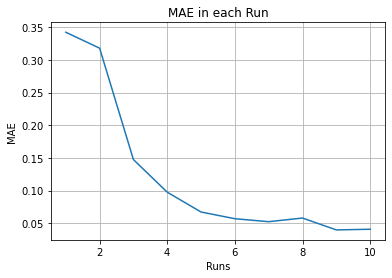

Validation MAE 3NN Increased(VORP): 0.122


In [72]:
# Graph to analyse how MAE is fluctuating in every run
plt.title('MAE in each Run')
plt.plot(np.arange(1,11),mae_list_threeinc_vorp)
plt.xlabel("Runs")
plt.ylabel("MAE")
plt.grid()
plt.show()

#Mean Absolute Error
val_mae_3inc_vorp = np.mean(mae_list_threeinc_vorp)
print("Validation MAE 3NN Increased(VORP):",round(val_mae_3inc_vorp,4))

MSE

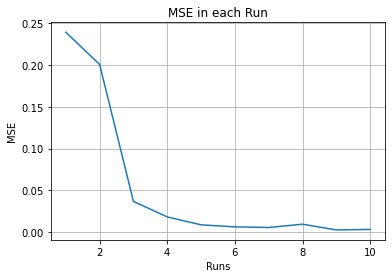

Validation MSE 3NN Increased(VORP): 0.0532


In [73]:
# Graph to analyse how MSE is fluctuating in every run
plt.title('MSE in each Run')
plt.plot(np.arange(1,11),mse_list_threeinc_vorp)
plt.xlabel("Runs")
plt.ylabel("MSE")
plt.grid()
plt.show()

#Mean Squared Error
val_mse_3inc_vorp = np.mean(mse_list_threeinc_vorp)
print("Validation MSE 3NN Increased(VORP):",round(val_mse_3inc_vorp,4))

TestSet Results

In [74]:
#Predicting Test Set Results 

predicted_y_test = sequential_three_increased_vorp.predict(
    X_test_original, batch_size=512, verbose=0, steps=None, callbacks=None, max_queue_size=10
  )

test_mae_3NNinc_vorp = mean_absolute_error(predicted_y_test, y_test_original)
test_mse_3NNinc_vorp = mean_squared_error(predicted_y_test, y_test_original)
print("Test MAE 3NN Increased(VORP) : ",round(test_mae_3NNinc_vorp,4))
print("Test MSE 3NN Increased(VORP) : ",round(test_mse_3NNinc_vorp,4))

Test MAE 3NN Increased(VORP) :  0.0357
Test MSE 3NN Increased(VORP) :  0.0023


### Evaluating Different Models on Test Scores

Now we will analyse the testset errors for all three models with the help of graphs

#### MAE

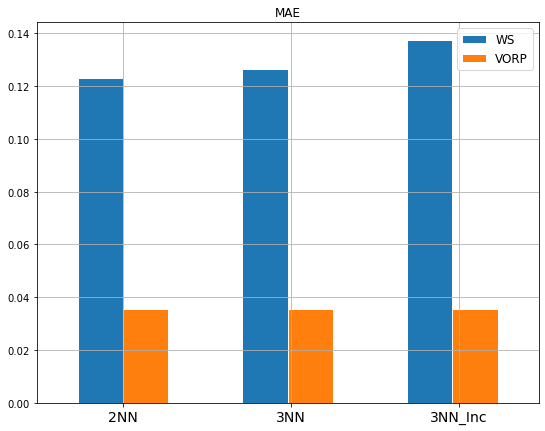

For 2NN(WS) MAE is 0.1231
For 2NN(VORP) MAE is 0.0355
For 3NN(WS) MAE is 0.1264
For 3NN(VORP) MAE is 0.0354
For 3NN Increased (WS) MAE is 0.1373
For 3NN Increased (VORP) MAE is 0.0357


In [75]:
data ={'WS' :  [test_mae_2NN_WS,test_mae_3NN_WS,test_mae_3NNinc_WS],
    'VORP' :  [test_mae_2NN_vorp,test_mae_3NN_vorp,test_mae_3NNinc_vorp],
    }
index=np.arange(3)
df=pd.DataFrame(data)
df.plot(kind='bar', width=0.55, edgecolor='white')
plt.grid()
plt.xticks(index*1.7*0.6,['2NN','3NN','3NN_Inc'],fontsize=14)
# plt.yticks(np.arange(0, 0.14,step=0.03),fontsize=18) 
plt.title("MAE")
plt.gcf().set_size_inches(9,7)
plt.tick_params(axis='x',labelrotation=0)
plt.legend(fontsize=12)
plt.show()
print("For 2NN(WS) MAE is {}".format(round(test_mae_2NN_WS,4)))
print("For 2NN(VORP) MAE is {}".format(round(test_mae_2NN_vorp,4)))
print("For 3NN(WS) MAE is {}".format(round(test_mae_3NN_WS,4)))
print("For 3NN(VORP) MAE is {}".format(round(test_mae_3NN_vorp,4)))
print("For 3NN Increased (WS) MAE is {}".format(round(test_mae_3NNinc_WS,4)))
print("For 3NN Increased (VORP) MAE is {}".format(round(test_mae_3NNinc_vorp,4)))


#### MSE

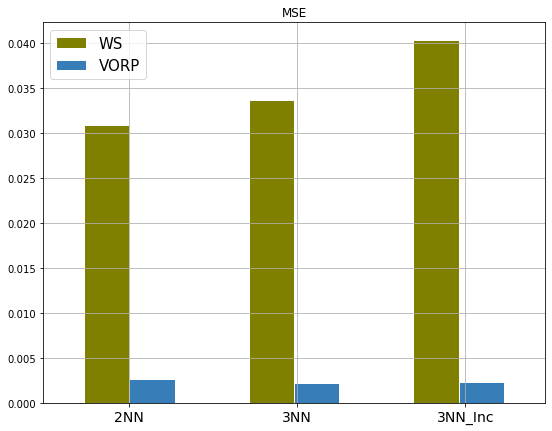

For 2NN(WS) MSE is 0.031
For 2NN(VORP) MSE is 0.0027
For 3NN(WS) MSE is 0.0337
For 3NN(VORP) MSE is 0.0022
For 3NN Increased (WS) MSE is 0.0403
For 3NN Increased (VORP) MSE is 0.0023


In [76]:
data ={'WS' :  [test_mse_2NN_WS,test_mse_3NN_WS,test_mse_3NNinc_WS],
    'VORP' :  [test_mse_2NN_vorp,test_mse_3NN_vorp,test_mse_3NNinc_vorp],
    }
index=np.arange(3)
df=pd.DataFrame(data)
df.plot(kind='bar', width=0.55, edgecolor='white',color=['olive','#377eb8'])
plt.grid()
plt.xticks(index*1.7*0.6,['2NN','3NN','3NN_Inc'],fontsize=14)
# plt.yticks(np.arange(0, 0.14,step=0.03),fontsize=18) 
plt.title("MSE")
plt.gcf().set_size_inches(9,7)
plt.tick_params(axis='x',labelrotation=0)
plt.legend(fontsize=15)
plt.show()
print("For 2NN(WS) MSE is {}".format(round(test_mse_2NN_WS,4)))
print("For 2NN(VORP) MSE is {}".format(round(test_mse_2NN_vorp,4)))
print("For 3NN(WS) MSE is {}".format(round(test_mse_3NN_WS,4)))
print("For 3NN(VORP) MSE is {}".format(round(test_mse_3NN_vorp,4)))
print("For 3NN Increased (WS) MSE is {}".format(round(test_mse_3NNinc_WS,4)))
print("For 3NN Increased (VORP) MSE is {}".format(round(test_mse_3NNinc_vorp,4)))


We can see that all three models have much lower MSE value than current state of the art player performance predictor. Also predicting a player's Value over replacement player has much better results than predicting his Win Shares